# IMPORT

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import warnings
import calendar
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Rectangle
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Load Dataset

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("muhammadehsan02/us-stock-market-and-commodities-data-2020-2024")

# print("Path to dataset files:", path)

In [3]:
df = pd.read_csv('/home/muhammad-rafif-rizqullah/Documents/Belajar/Portofolio/data_analyst/Us_stock_commodity_analyst/US_stock_commodity/US_Stock_Data.csv')
df.describe()

,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
count,1013.000000,1013.000000,1009.000000,1013.000000,9.900000e+02,1013.000000,976.000000,1.013000e+03,636.000000,1.013000e+03,...,1013.000000,1.013000e+03,1013.000000,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1011.000000
mean,506.000000,3.726667,129091.932607,69.853475,3.571739e+05,3.726843,37606.752049,4.924137e+07,9082.515723,1.958002e+07,...,219.738065,4.629821e+07,2918.400790,422.035479,7.012043e+06,137.426209,7.452566e+07,252.151046,2.504895e+07,189442.393670
std,292.572213,1.943030,64035.426727,21.986697,1.864309e+05,0.646524,39192.315092,3.251389e+08,8876.538587,1.469409e+08,...,128.668703,1.878815e+07,2715.637488,119.765870,6.788094e+06,27.321896,3.376809e+07,72.949246,1.635122e+07,104007.872337
min,0.000000,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,2.600000e+02,0.000000,7.518000e+04,...,49.100000,9.790000e+06,120.000000,166.370000,1.140000e+06,81.820000,2.162000e+07,88.910000,5.470000e+06,0.000000
25%,253.000000,2.447000,88680.000000,54.760000,2.751800e+05,3.408000,380.000000,7.142000e+04,1120.000000,5.272300e+05,...,131.980000,3.348000e+07,760.000000,338.630000,3.780000e+06,114.770000,5.192000e+07,195.210000,1.612000e+07,142985.000000
50%,506.000000,2.880000,125980.000000,72.910000,3.450350e+05,3.800500,31635.000000,1.288800e+05,6070.000000,9.665800e+05,...,179.130000,4.368000e+07,2040.000000,431.600000,5.380000e+06,142.300000,6.515000e+07,262.010000,2.107000e+07,181200.000000
75%,759.000000,4.805000,164810.000000,82.810000,4.269225e+05,4.251500,70982.500000,3.860000e+05,15287.500000,3.670000e+06,...,272.470000,5.640000e+07,4090.000000,509.640000,7.890000e+06,161.060000,8.683000e+07,313.190000,2.903000e+07,231500.000000
max,1012.000000,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,4.470000e+09,42830.000000,1.790000e+09,...,661.600000,1.534600e+08,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,813410.000000


# Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Date               1013 non-null   object 
 2   Natural_Gas_Price  1013 non-null   float64
 3   Natural_Gas_Vol.   1009 non-null   float64
 4   Crude_oil_Price    1013 non-null   float64
 5   Crude_oil_Vol.     990 non-null    float64
 6   Copper_Price       1013 non-null   float64
 7   Copper_Vol.        976 non-null    float64
 8   Bitcoin_Price      1013 non-null   object 
 9   Bitcoin_Vol.       1013 non-null   int64  
 10  Platinum_Price     1013 non-null   object 
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1013 non-null   object 
 13  Ethereum_Vol.      1013 non-null   int64  
 14  S&P_500_Price      1013 non-null   object 
 15  Nasdaq_100_Price   1013 non-null   object 
 16  Nasdaq_100_Vol.    1012 

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

In [6]:
null_col = df.columns[df.isnull().sum() > 0]
null_col

Index(['Natural_Gas_Vol.', 'Crude_oil_Vol.', 'Copper_Vol.', 'Platinum_Vol.',
       'Nasdaq_100_Vol.', 'Silver_Vol.', 'Gold_Vol.'],
      dtype='object')

In [7]:
for col in null_col:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
to_float = df.select_dtypes(include=['object'])
to_float.columns

Index(['Bitcoin_Price', 'Platinum_Price', 'Ethereum_Price', 'S&P_500_Price',
       'Nasdaq_100_Price', 'Berkshire_Price', 'Gold_Price'],
      dtype='object')

In [9]:
for col in to_float:
    try:
        df[col] = df[col].astype('float64')
    except :
        df[col] = df[col].str.replace(',','').astype('float64')

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,Platinum_Vol.,Ethereum_Price,Ethereum_Vol.,S&P_500_Price,Nasdaq_100_Price,Nasdaq_100_Vol.,Apple_Price,Apple_Vol.,Tesla_Price,Tesla_Vol.,Microsoft_Price,Microsoft_Vol.,Silver_Price,Silver_Vol.,Google_Price,Google_Vol.,Nvidia_Price,Nvidia_Vol.,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,2024-02-02,2.079,129091.932607,72.28,357173.919192,3.8215,37606.752049,43194.7,42650,901.6,9082.515723,2309.28,246890,4958.61,17642.73,315620000.0,185.85,102550000,187.91,110610000,411.22,28260000,22.796,64216.80455,142.38,62500000,661.60,47660000,589498.0,10580,564.64,4030000,171.81,117220000,474.99,84710000,2053.7,189442.39367
1,2024-01-02,2.050,161340.000000,73.82,577940.000000,3.8535,37606.752049,43081.4,47690,922.3,9082.515723,2304.28,323610,4906.19,17344.71,240640000.0,186.86,53490000,188.86,90680000,403.78,29230000,23.236,85160.00000,141.16,37120000,630.27,36020000,581600.0,9780,567.51,3150000,159.28,66360000,394.78,25140000,2071.1,260920.00000
2,2024-01-31,2.100,142860.000000,75.85,344490.000000,3.9060,37606.752049,42580.5,56480,932.6,9082.515723,2283.14,408790,4848.87,17137.24,366450000.0,184.40,54830000,187.29,102270000,397.58,46780000,23.169,66910.00000,140.10,71370000,615.27,45070000,578020.0,9720,564.11,4830000,155.20,49690000,390.14,20010000,2067.4,238370.00000
3,2024-01-30,2.077,139750.000000,77.82,347240.000000,3.9110,37606.752049,42946.2,55130,931.7,9082.515723,2343.11,387120,4924.97,17476.71,236210000.0,188.04,55270000,191.59,105540000,408.59,29340000,23.225,53370.00000,151.46,33060000,627.74,39600000,584680.0,9750,562.85,6120000,159.00,42290000,400.06,18610000,2050.9,214590.00000
4,2024-01-29,2.490,3590.000000,76.78,331930.000000,3.8790,37606.752049,43299.8,45230,938.3,9082.515723,2317.79,318840,4927.93,17596.27,238750000.0,191.73,46890000,190.93,123600000,409.72,23290000,23.134,330.00000,153.51,27590000,624.65,33900000,578800.0,13850,575.79,6880000,161.26,42840000,401.02,17790000,2034.9,1780.00000


# Correlation

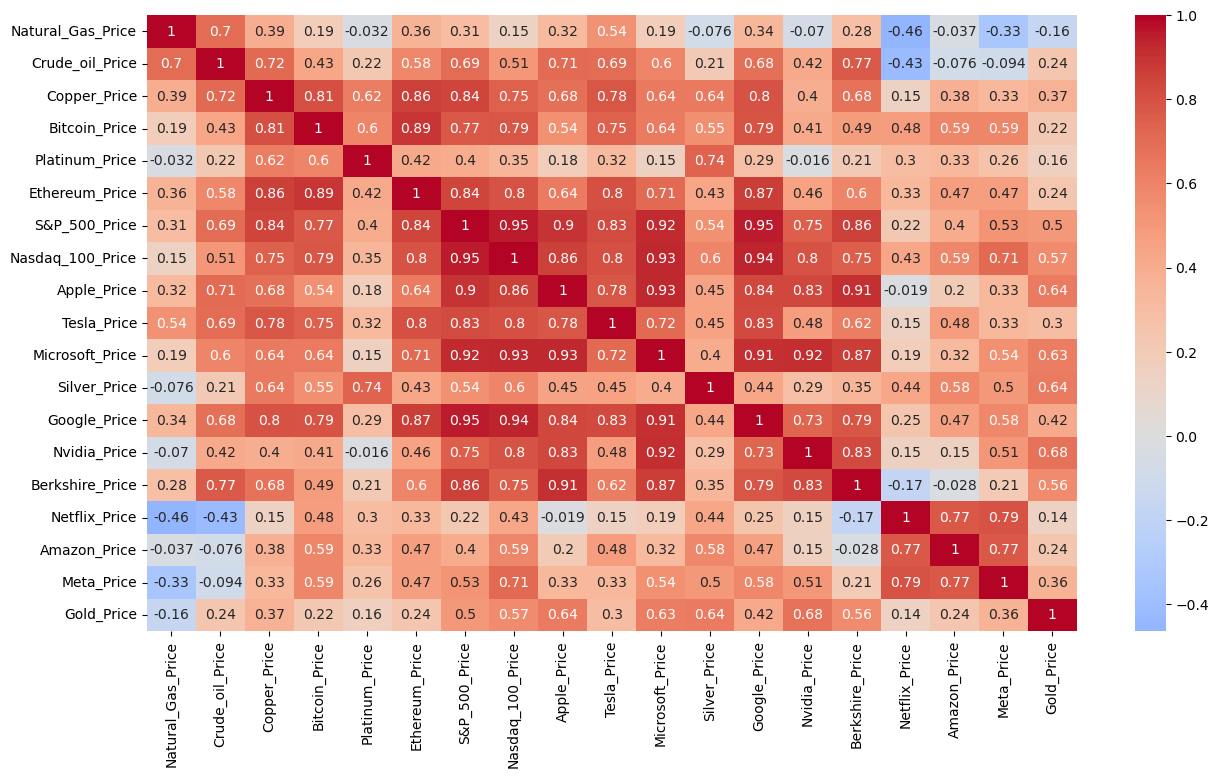

In [12]:
price_columns = [col for col in df.columns if 'Price' in col]

corr_price = df[price_columns].corr()

plt.figure(figsize=(15,8))
sns.heatmap(corr_price, cmap='coolwarm', annot=True, center=0)
plt.show()

In [13]:
correlation = []
for target in price_columns :
    for col in price_columns:
         if col != target:
             corr_value = df[target].corr(df[col])

             if abs(corr_value) > 0.5:
                 correlation.append({
                     'Target' : target,
                     'Fitur' : col,
                     'Korelasi': corr_value
                 })
corr_df = pd.DataFrame(correlation)
corr_df = corr_df.sort_values('Korelasi', ascending=False)


In [14]:
df = df.set_index('Date')

In [15]:
pd.set_option('display.max_rows', None)
df = df.sort_index()
df = df[df.index.year != 2024]
norm_df = df[price_columns]

In [16]:
norm_df.tail()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2023-12-22,2.610,73.56,3.9050,43968.9,981.8,2324.23,4754.63,16777.40,193.60,252.54,374.58,24.565,141.49,488.30,542600.0,486.76,153.42,353.39,2059.6
2023-12-26,2.550,75.57,3.9020,42513.3,995.6,2230.74,4774.75,16878.46,193.05,256.61,374.66,24.396,141.52,492.79,543635.0,491.19,153.41,354.83,2060.4
2023-12-27,2.619,74.11,3.9560,43446.5,1013.5,2378.63,4781.58,16906.80,193.15,261.44,374.07,24.570,140.37,494.17,543750.0,491.79,153.34,357.83,2083.4
2023-12-28,2.557,71.77,3.9245,42581.1,1023.2,2344.47,4783.35,16898.47,193.58,253.18,375.28,24.372,140.23,495.22,545000.0,490.51,153.38,358.32,2083.5
2023-12-29,2.514,71.65,3.8915,42072.4,1009.2,2299.24,4769.83,16825.93,192.53,248.48,376.04,24.025,139.69,495.22,542625.0,486.88,151.94,353.96,2071.8


In [17]:
for column in norm_df[price_columns]:
    if column in norm_df.columns:
        first = norm_df[column].dropna().iloc[0]
        norm_df[column] = (norm_df[column] / first) * 100
        norm_df[column] = norm_df[column].rolling(window=30, min_periods=1).mean()

norm_df.head()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2020-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-05,109.546314,98.695224,103.051859,116.442720,104.137116,128.136518,107.290225,108.227640,109.995019,122.819315,107.382815,103.411041,109.773140,108.161922,102.435407,107.030048,109.911940,113.367794,103.440367
2020-01-06,110.291955,123.961924,106.608536,128.791143,111.157465,146.353629,112.756392,114.891622,117.859317,144.049844,111.653847,113.818173,116.581972,120.410290,103.454545,110.348458,116.448265,124.014202,105.621884
2020-01-07,109.042218,141.986706,111.324002,131.352339,112.447851,152.325667,116.097956,120.495633,126.178815,166.168224,117.383801,117.932995,120.149728,129.512918,103.143062,116.108410,125.060279,130.220865,107.177642
2020-01-09,119.080025,155.696701,116.801285,140.978233,116.697260,192.006487,121.428456,129.237499,145.498921,231.595016,123.789363,135.314645,126.156080,149.096594,107.581627,123.459679,136.731314,141.199248,110.612040


In [18]:
norm_df.describe()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,235.820668,340.838325,170.091932,428.738383,136.021477,1245.314092,159.655876,171.303024,231.367161,642.389951,171.101179,162.362553,194.016780,339.019145,160.055094,115.153586,143.233666,155.128378,114.965997
std,111.035776,103.451188,27.749629,207.515829,11.785162,718.969819,19.347719,25.042069,51.129730,238.994046,31.351557,17.245723,40.113216,167.136083,29.466966,28.472189,23.048821,35.847666,5.358588
min,100.000000,98.695224,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,56.974108,100.000000,83.954261,100.000000
25%,156.900336,243.241835,150.004972,279.850694,128.525298,385.129798,143.490039,157.192313,195.152471,491.858515,138.853680,150.166798,152.711283,204.520460,127.626051,95.678422,124.889838,126.967105,111.834025
50%,187.508927,364.605285,175.764877,414.052070,133.509248,1290.897341,165.638757,175.823779,242.923515,717.482866,174.510661,166.658681,204.512099,296.292030,163.507547,114.619955,137.607366,155.271930,114.183319
75%,303.105440,410.580174,194.035682,585.956491,141.784348,1760.729643,174.940059,192.292992,268.643671,802.064901,193.008514,172.771143,226.326376,401.036284,183.492743,139.530209,163.878639,183.926953,118.971660
max,511.718126,530.830461,209.183876,867.359142,164.576090,2806.556342,184.685705,211.476762,311.889424,1017.686397,236.318892,190.906512,249.837266,751.180956,206.070354,173.100692,183.803683,221.526316,126.542667


In [19]:

norm_df = norm_df.dropna()

norm_df.head()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2020-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-05,109.546314,98.695224,103.051859,116.442720,104.137116,128.136518,107.290225,108.227640,109.995019,122.819315,107.382815,103.411041,109.773140,108.161922,102.435407,107.030048,109.911940,113.367794,103.440367
2020-01-06,110.291955,123.961924,106.608536,128.791143,111.157465,146.353629,112.756392,114.891622,117.859317,144.049844,111.653847,113.818173,116.581972,120.410290,103.454545,110.348458,116.448265,124.014202,105.621884
2020-01-07,109.042218,141.986706,111.324002,131.352339,112.447851,152.325667,116.097956,120.495633,126.178815,166.168224,117.383801,117.932995,120.149728,129.512918,103.143062,116.108410,125.060279,130.220865,107.177642
2020-01-09,119.080025,155.696701,116.801285,140.978233,116.697260,192.006487,121.428456,129.237499,145.498921,231.595016,123.789363,135.314645,126.156080,149.096594,107.581627,123.459679,136.731314,141.199248,110.612040


In [20]:
norm_df.columns

Index(['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Bitcoin_Price',
       'Platinum_Price', 'Ethereum_Price', 'S&P_500_Price', 'Nasdaq_100_Price',
       'Apple_Price', 'Tesla_Price', 'Microsoft_Price', 'Silver_Price',
       'Google_Price', 'Nvidia_Price', 'Berkshire_Price', 'Netflix_Price',
       'Amazon_Price', 'Meta_Price', 'Gold_Price'],
      dtype='object')

# EDA Musiman

In [ ]:
colorsbrand_colors = {
    # Tech Companies - Made more vibrant and distinctive
    'Apple_Price': "#1D1D1F",      # Apple's signature dark gray (more contrast)
    'Tesla_Price': "#525050",      # Tesla red (brighter)
    'Microsoft_Price': "#0078D4",  # Microsoft blue (official bright blue)
    'Google_Price': "#4285F4",     # Google blue (official bright blue)
    'Nvidia_Price': '#76B900',     # Nvidia green (kept - already good)
    'Netflix_Price': '#E50914',    # Netflix red (kept - already good)
    'Amazon_Price': '#FF9900',     # Amazon orange (kept - already good)
    'Meta_Price': '#1877F2',       # Meta blue (kept - already good)
    
    # Cryptocurrencies - Enhanced contrast
    'Bitcoin_Price': '#F7931A',    # Bitcoin orange (kept - already good)
    'Ethereum_Price': '#627EEA',   # Ethereum blue (kept - already good)
    
    # Precious Metals - More distinctive colors
    'Gold_Price': "#FFD700",       # Pure gold color (removed transparency)
    'Silver_Price': '#C0C0C0',     # Silver (kept - already good)
    'Copper_Price': '#B87333',     # Copper (kept - already good)
    'Platinum_Price': '#E5E4E2',   # Platinum (kept - already good)
    
    # Commodities - Improved contrast
    'Crude_oil_Price': '#000000',  # Pure black for oil (maximum contrast)
    'Natural_Gas_Price': '#4169E1', # Royal blue (more vibrant than brown)
    
    # Indices - More contrasting colors
    'S&P_500_Price': '#0052CC',    # Darker blue (better contrast)
    'Nasdaq_100_Price': '#FF6B35', # Bright orange-red (more vibrant)
    'Berkshire_Price': '#006B3C'   # Forest green (brighter than original)
}

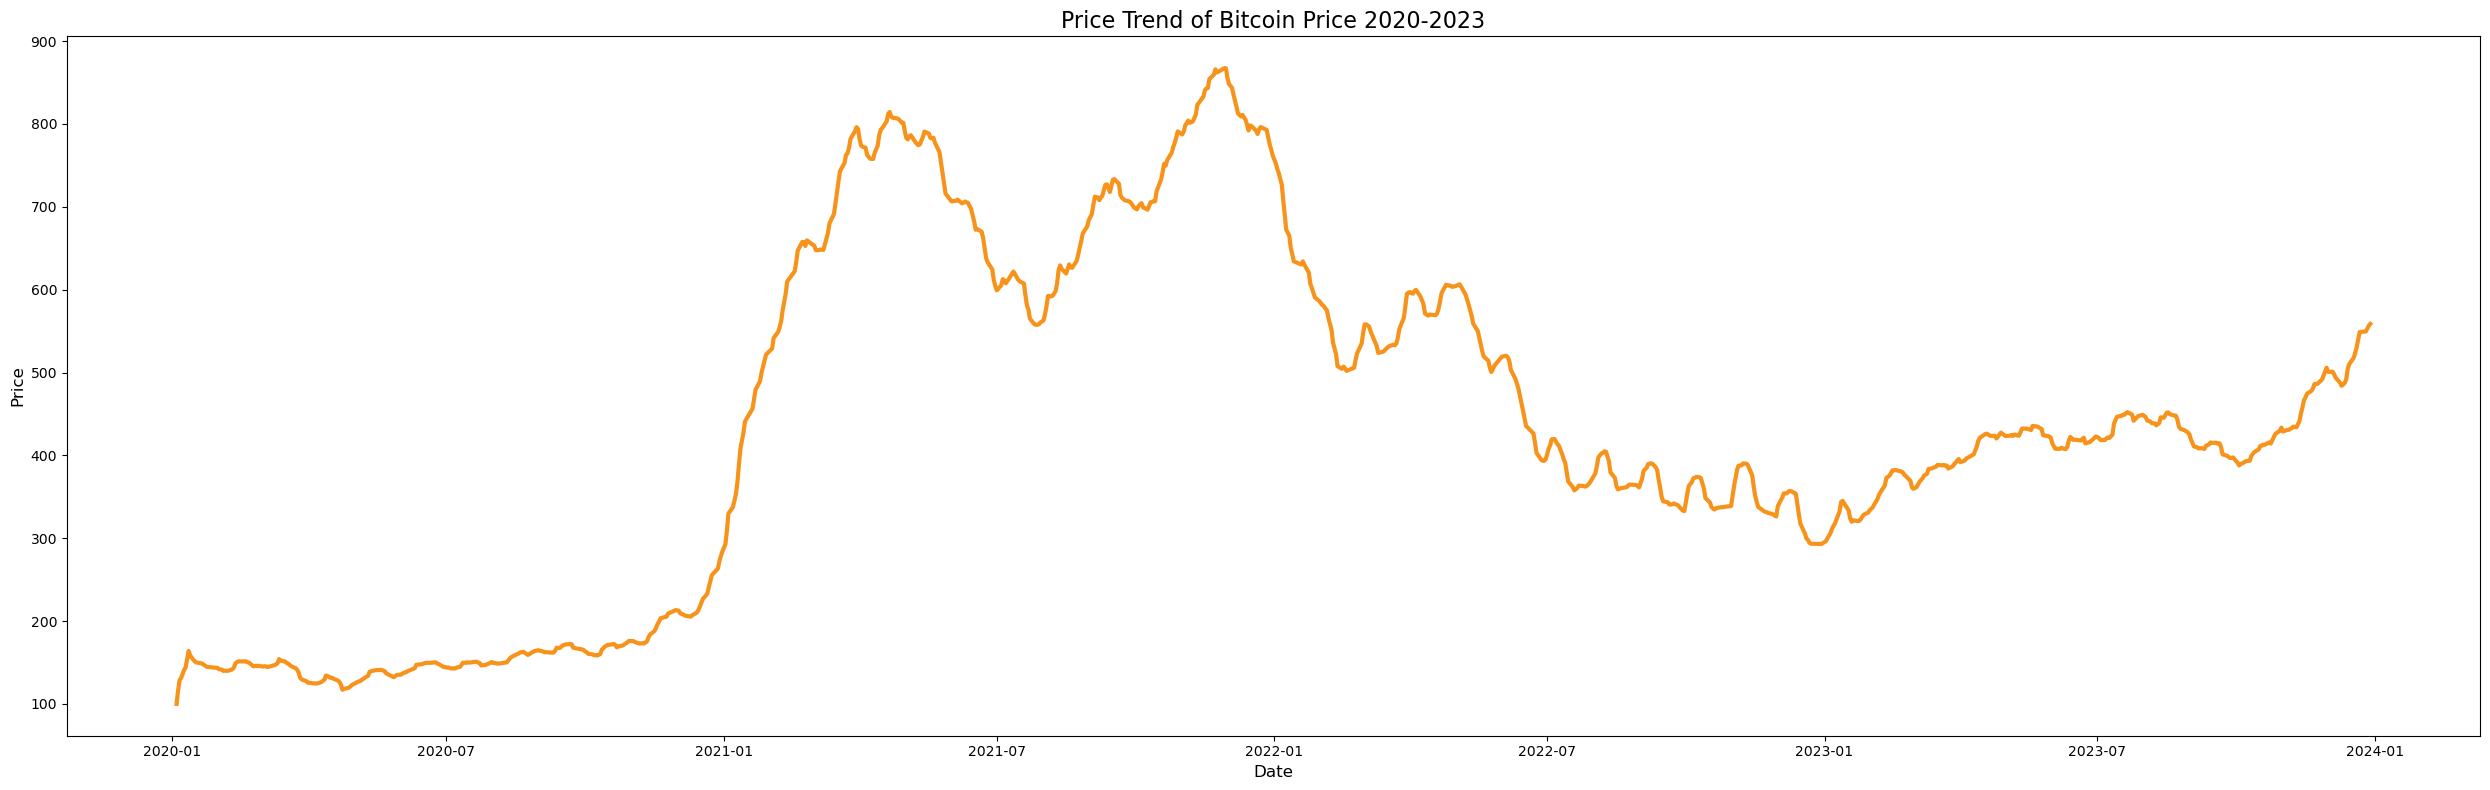

In [22]:
asset = 'Bitcoin_Price'

plt.figure(figsize=(25,8))
plt.plot(norm_df[asset], color=colorsbrand_colors[asset], label=asset.replace('_', ''), linewidth=3)

plt.title(f"Price Trend of {asset.replace('_', ' ')} 2020-2023", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
import plotly.graph_objects as go
import streamlit as st

# Convert matplotlib to plotly
asset = 'Ethereum_Price'

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=norm_df.index,
    y=norm_df[asset],
    mode='lines',
    name=asset.replace('_', ''),
    line=dict(color=colorsbrand_colors[asset], width=3),
    hovertemplate='Date: %{x}<br>Price: $%{y:,.2f}<extra></extra>'
))

fig.update_layout(
    title=f"Price Trend of {asset.replace('_', ' ')} 2020-2023",
    xaxis_title='Date',
    yaxis_title='Price',
    width=1500,
    height=700,
    template='plotly_white'
)

# Show in Streamlit
# st.plotly_chart(fig, use_container_width=True)

# Or show in Jupyter/Python
fig.show()

In [24]:
print(f"Harga teringgi : {norm_df[asset].max()} pada {norm_df[asset].idxmax()}")
print(f"Harga terendah : {norm_df[asset].min()} pada {norm_df[asset].idxmin()}")
print(f"Rata-rata harga : {norm_df[asset].mean()}")
print(f"Harga perawalan  {asset} : {norm_df[asset].iloc[0]} pada {norm_df.index[0]}")
print(f"Harga perakhiran {asset} : {norm_df[asset].iloc[-1]} pada {norm_df.index[-1]}")

Harga teringgi : 2806.55634183498 pada 2021-11-30 00:00:00
Harga terendah : 100.0 pada 2020-01-04 00:00:00
Rata-rata harga : 1245.3140920330347
Harga perawalan  Ethereum_Price : 100.0 pada 2020-01-04 00:00:00
Harga perakhiran Ethereum_Price : 1510.6535947712416 pada 2023-12-29 00:00:00


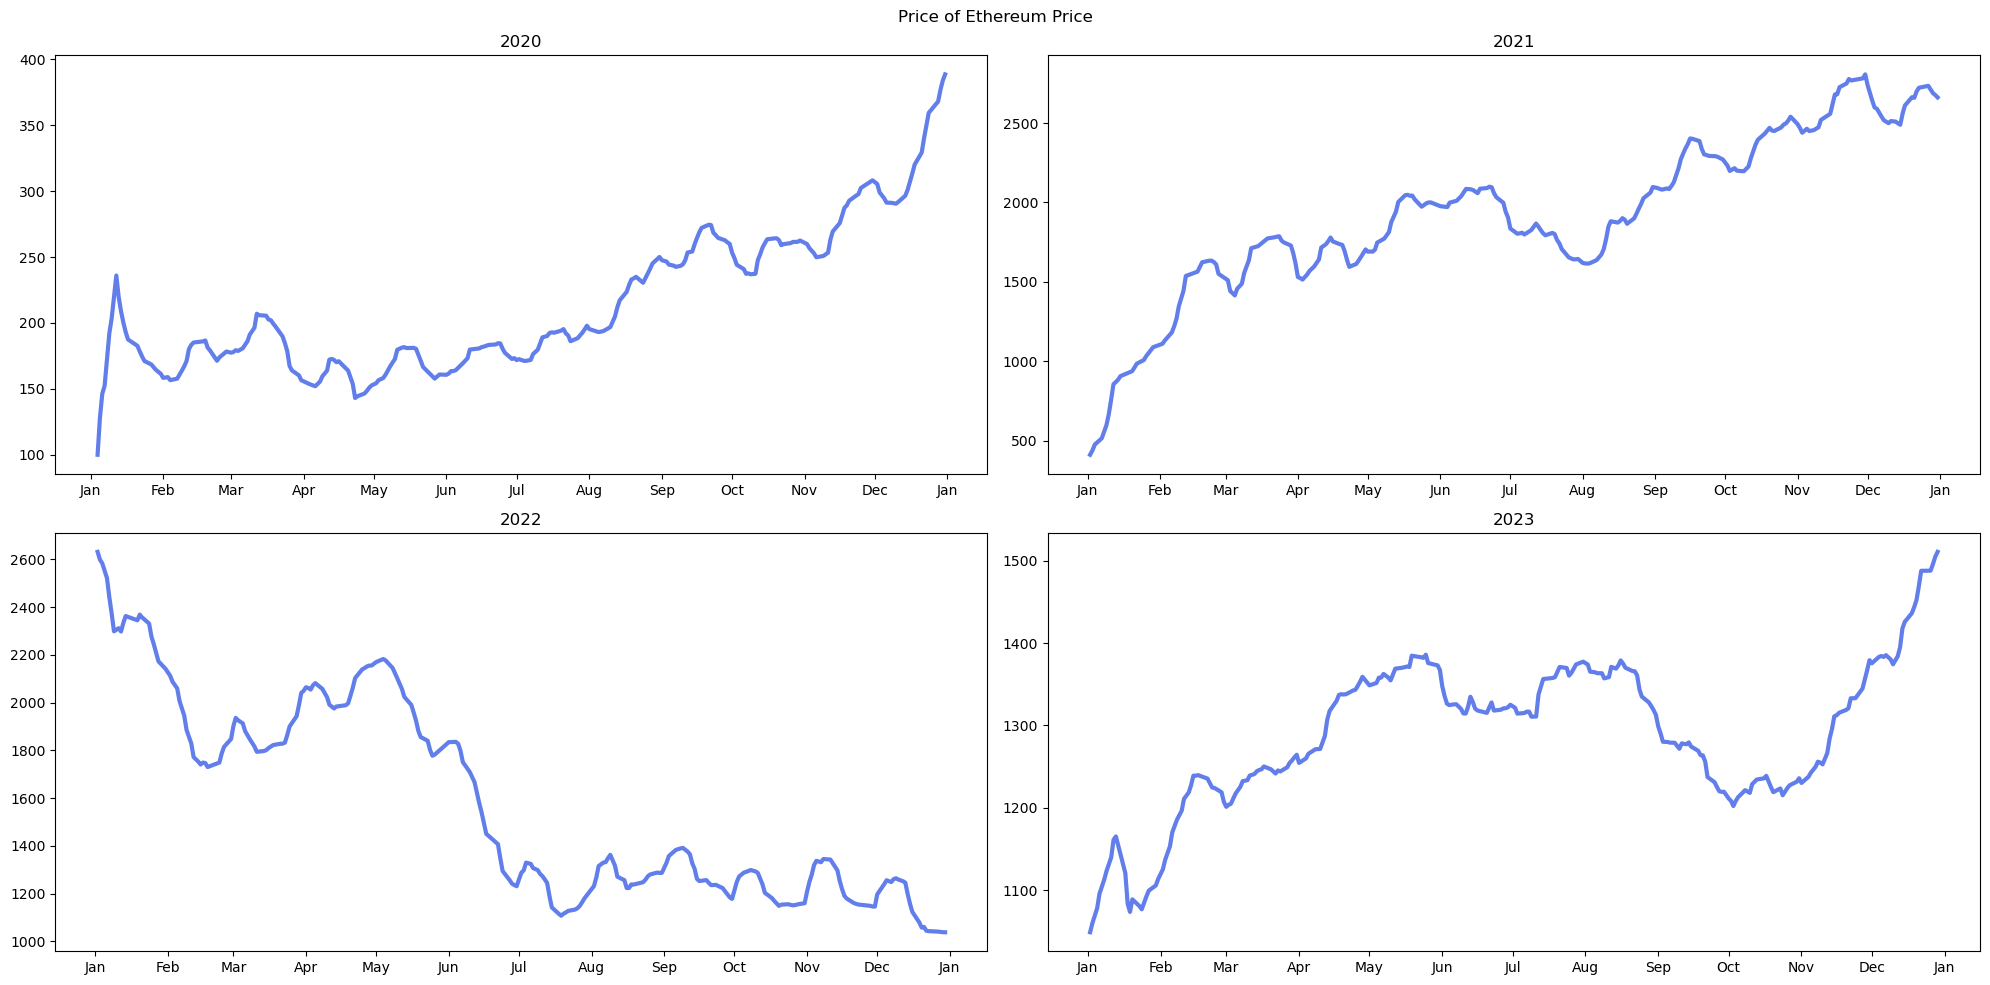

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

fig.suptitle(f"Price of {asset.replace('_', ' ')}")

years = norm_df.index.year.unique()

for i, year in enumerate(years):
  ax = axes[i//2, i%2]

  year_df = norm_df[norm_df.index.year == year]

  ax.plot(year_df.index, year_df[asset], label=asset.replace('_', ' '), color=colorsbrand_colors[asset], linewidth=3 )
  ax.set_title(f'{year}')
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
  ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()


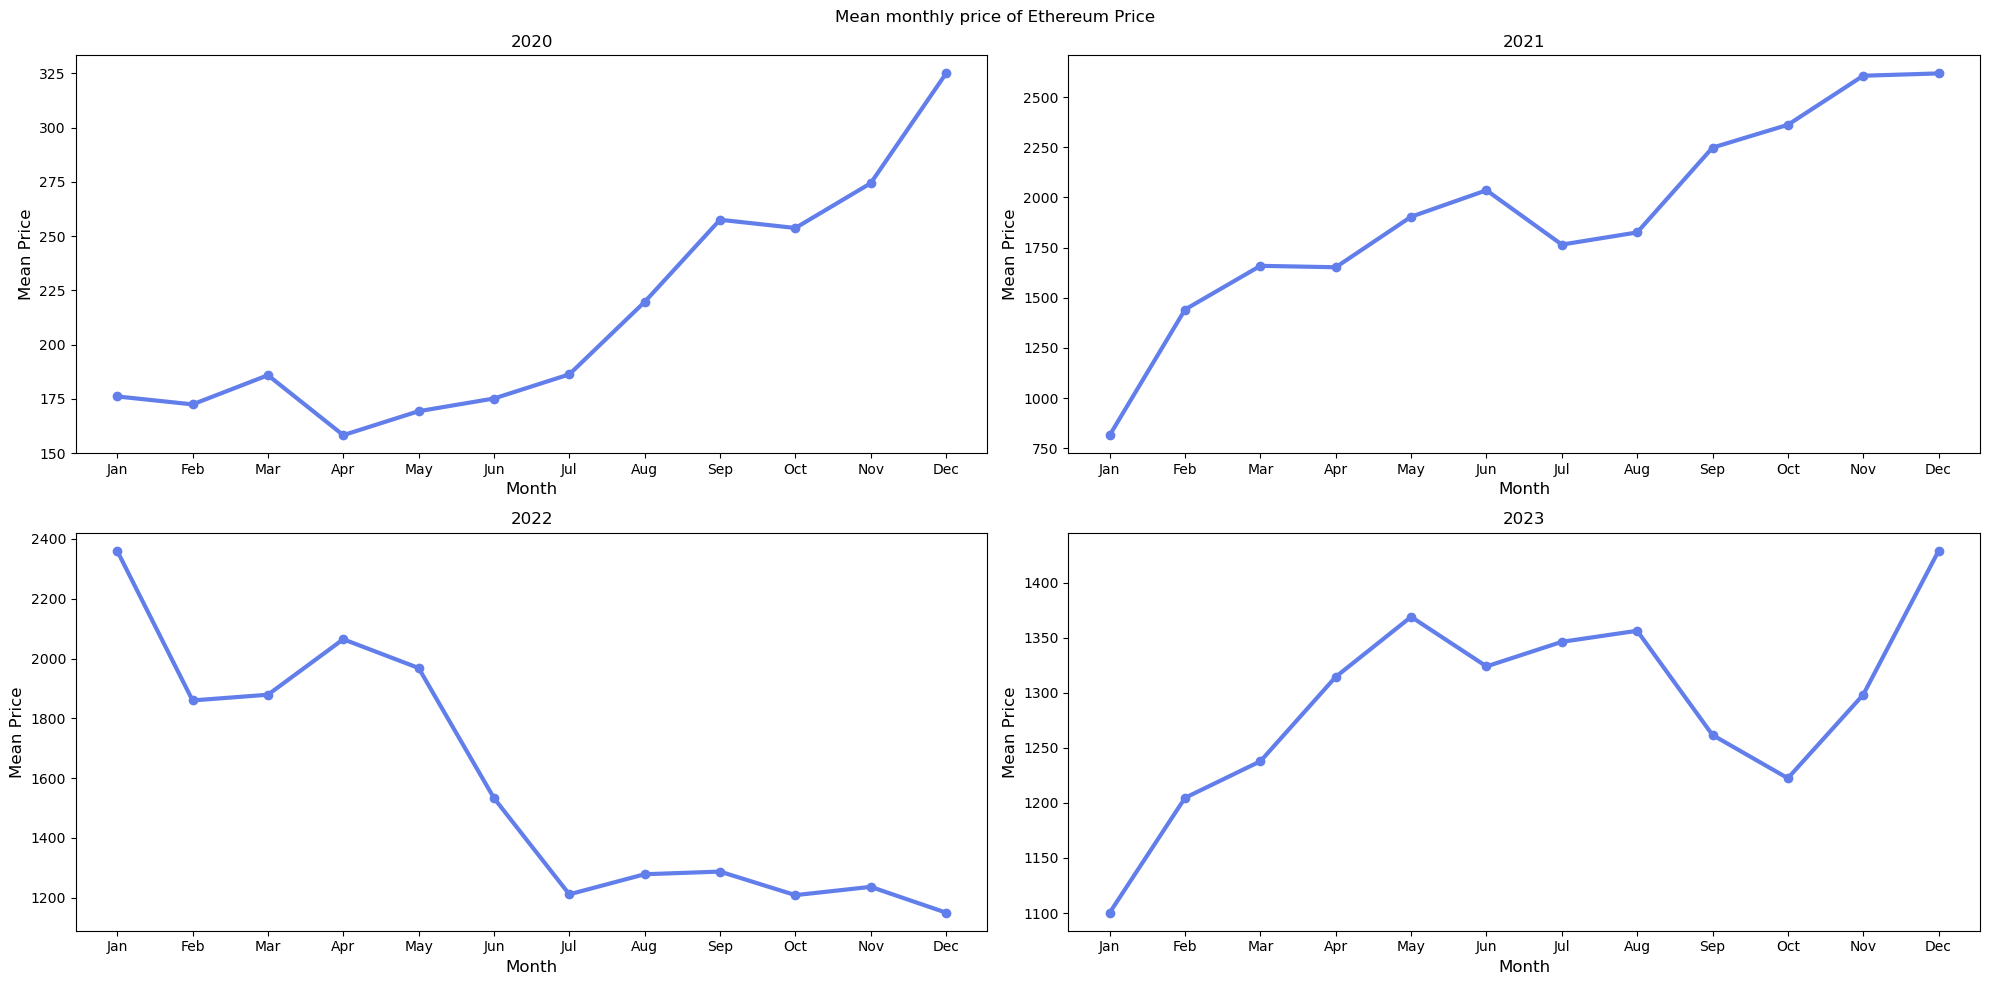

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle(f"Mean monthly price of {asset.replace('_', ' ')}")

mean_monthly = norm_df.groupby(norm_df.index.to_period('M'))[asset].mean()

years = mean_monthly.index.year.unique()

for i, year in enumerate(years):
    ax = axes[i//2, i%2]
    years = mean_monthly[mean_monthly.index.year == year]

    months = [month.month for month in years.index]

    ax.plot(months, years.values, color=colorsbrand_colors[asset], marker='o', linewidth=3)
    ax.set_title(year)
    ax.set_ylabel('Mean Price', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list(calendar.month_abbr[1:]))

plt.tight_layout()
plt.show()

In [27]:
print(f"Rata-rata Tertinggi tahun 2020 : {mean_monthly[mean_monthly.index.year == 2020].max():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2020].idxmax().month]}")
print(f"Rata-rata Terendah tahun 2020 : {mean_monthly[mean_monthly.index.year == 2020].min():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2020].idxmin().month]}")
print(f"Rata-rata Tertinggi tahun 2021 : {mean_monthly[mean_monthly.index.year == 2021].max():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2021].idxmax().month]}")   
print(f"Rata-rata Terendah tahun 2021 : {mean_monthly[mean_monthly.index.year == 2021].min():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2021].idxmin().month]}")
print(f"Rata-rata Tertinggi tahun 2022 : {mean_monthly[mean_monthly.index.year == 2022].max():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2022].idxmax().month]}")   
print(f"Rata-rata Terendah tahun 2022 : {mean_monthly[mean_monthly.index.year == 2022].min():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2022].idxmin().month]}")
print(f"Rata-rata Tertinggi tahun 2023 : {mean_monthly[mean_monthly.index.year == 2023].max():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2023].idxmax().month]}")
print(f"Rata-rata Terendah tahun 2023 : {mean_monthly[mean_monthly.index.year == 2023].min():.3f} pada {calendar.month_name[mean_monthly[mean_monthly.index.year == 2023].idxmin().month]}")

Rata-rata Tertinggi tahun 2020 : 324.979 pada December
Rata-rata Terendah tahun 2020 : 158.261 pada April
Rata-rata Tertinggi tahun 2021 : 2617.616 pada December
Rata-rata Terendah tahun 2021 : 815.697 pada January
Rata-rata Tertinggi tahun 2022 : 2359.937 pada January
Rata-rata Terendah tahun 2022 : 1149.810 pada December
Rata-rata Tertinggi tahun 2023 : 1428.758 pada December
Rata-rata Terendah tahun 2023 : 1100.390 pada January


In [28]:
df_2020 = norm_df[norm_df.index.year == 2020]
month_2020 = df_2020.index.month.unique()

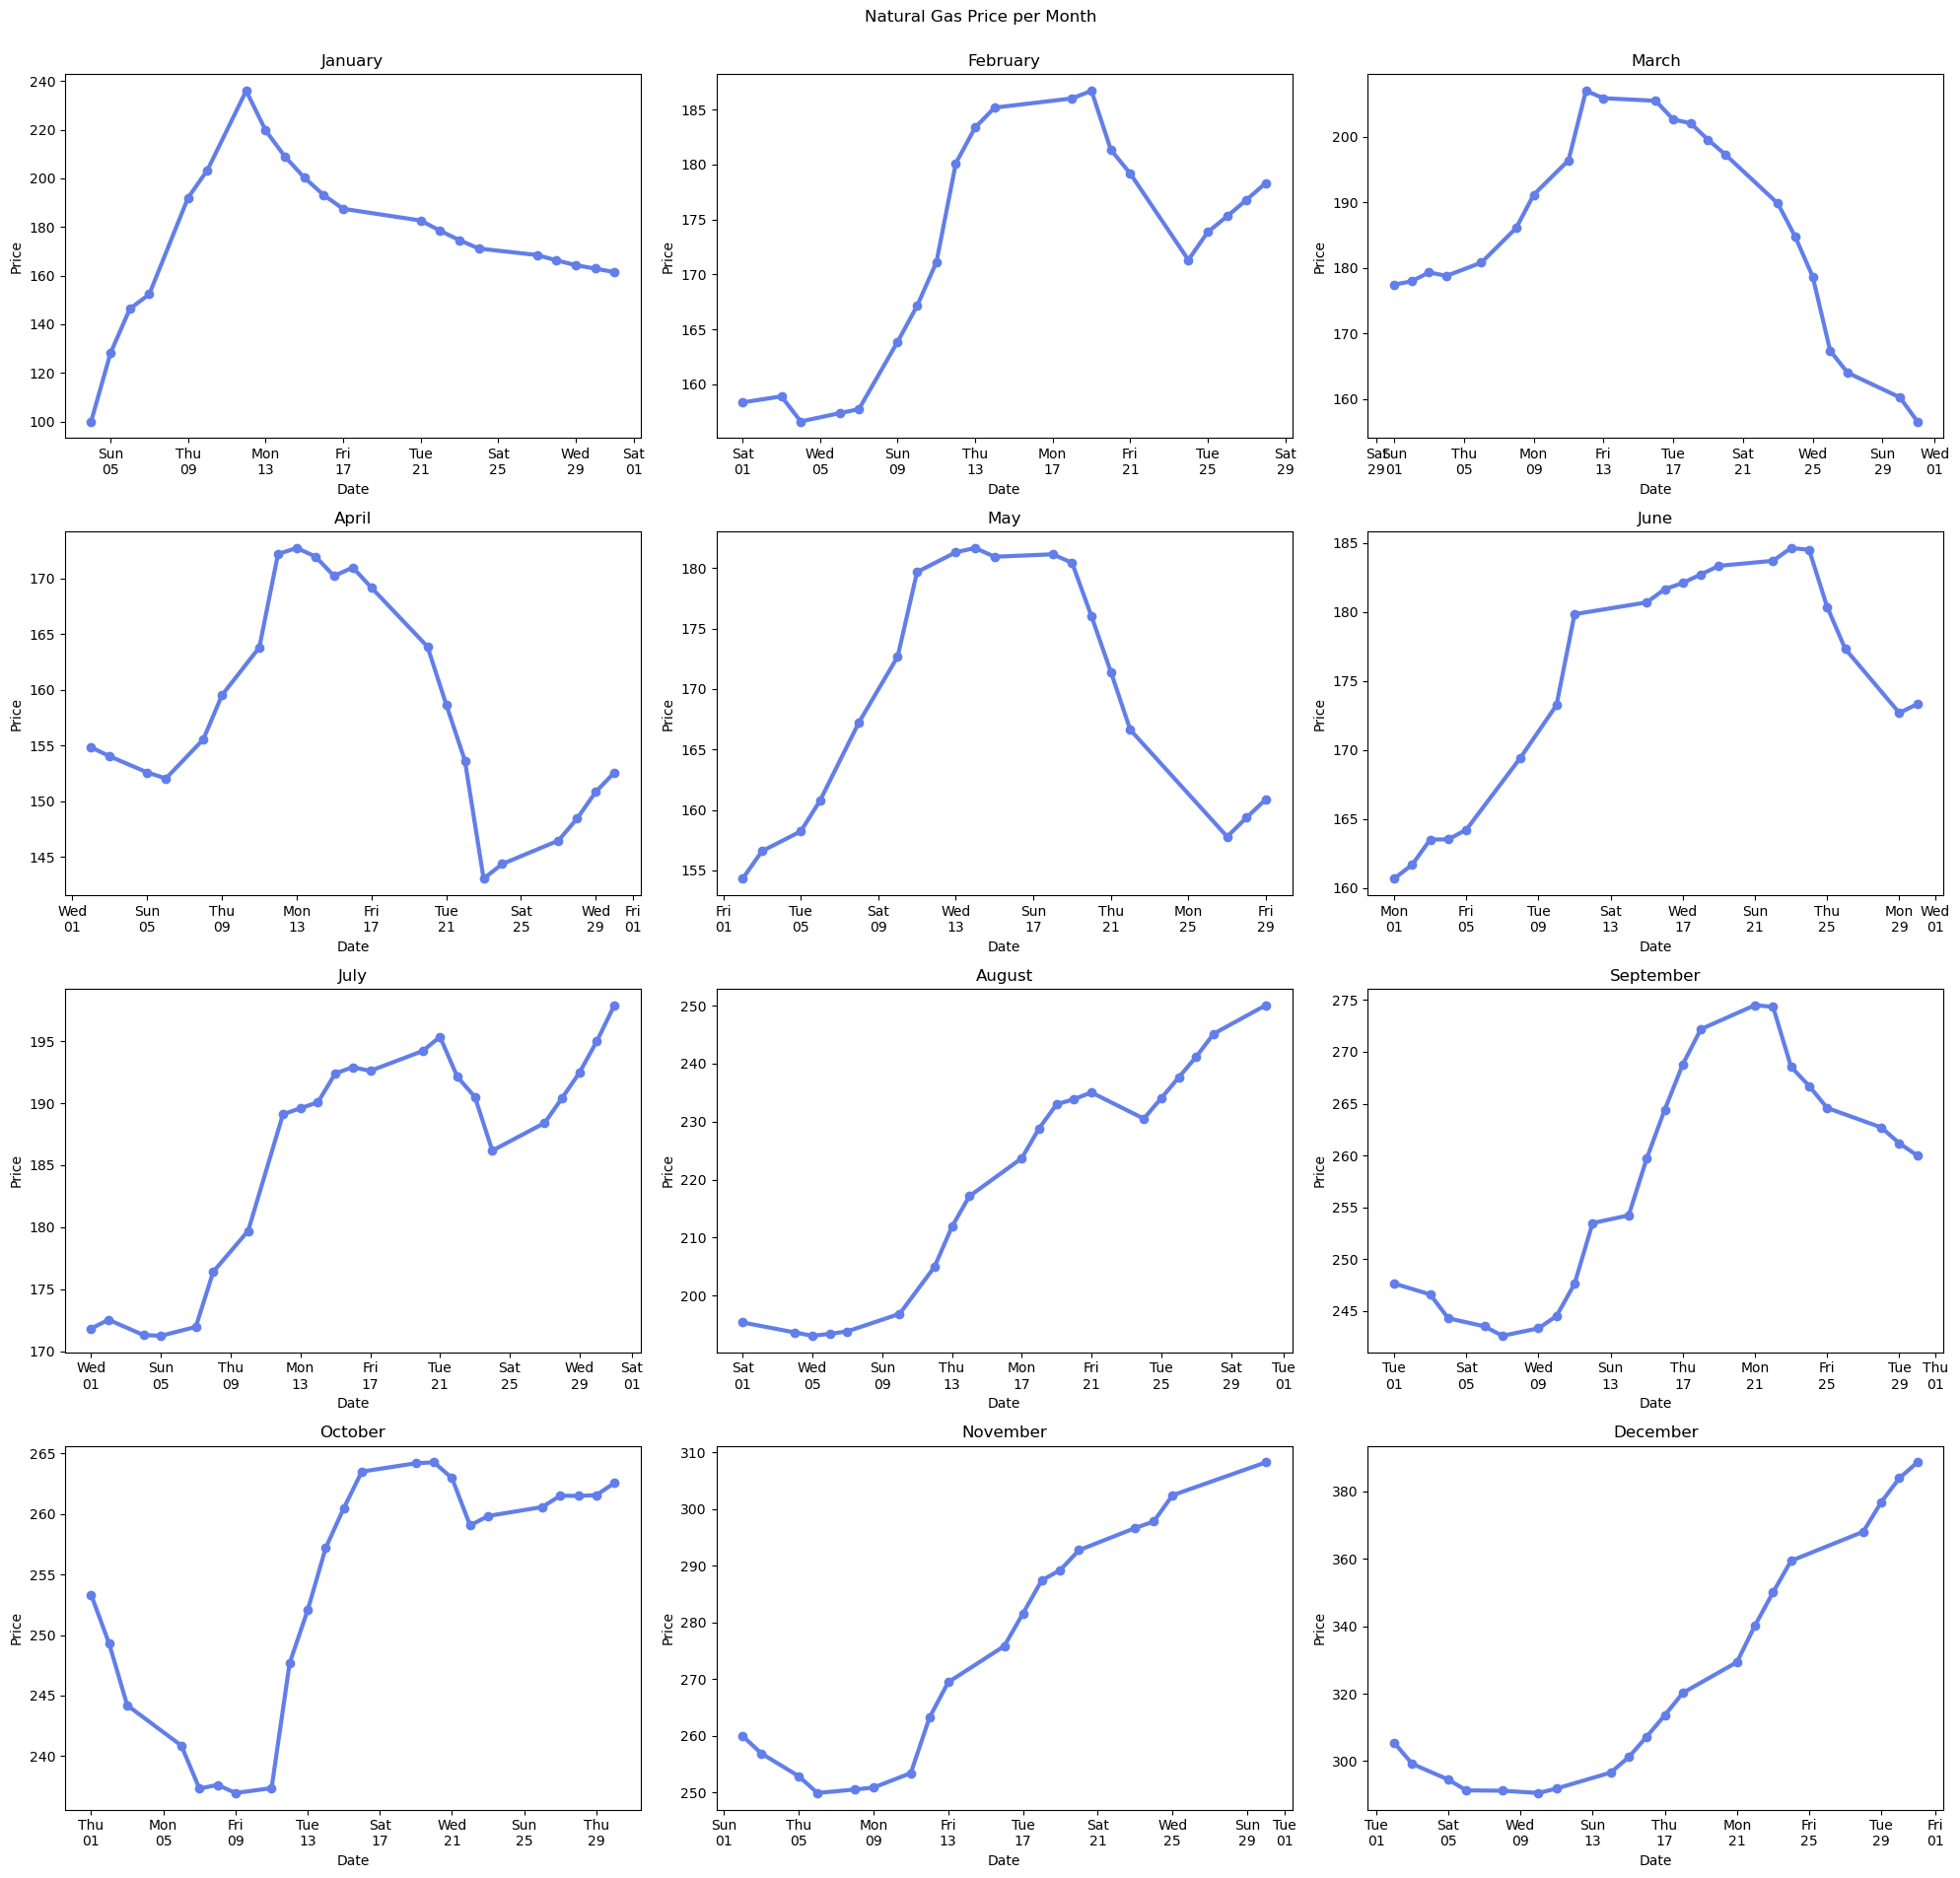

In [29]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
fig.suptitle('Natural Gas Price per Month', y=0.98)

df_2020 = norm_df[norm_df.index.year == 2020]
month_2020 = df_2020.index.month.unique()

for i, month in enumerate(month_2020):
  ax = axes[i//3, i%3]

  month_df = df_2020[df_2020.index.month == month]

  ax.plot(month_df.index, month_df[asset], label=asset.replace('_', ''), color=colorsbrand_colors[asset], marker='o', linewidth=3)
  ax.set_title(f'{calendar.month_name[month]}')
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d'))
  ax.set_xlabel('Date')
  ax.set_ylabel('Price')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()



In [30]:
for i, month in enumerate(month_2020):
  month_df = df_2020[df_2020.index.month == month]
  print(f"{calendar.month_name[month]}")
  print(f"harga awal : {month_df[asset].iloc[0]:.3f} pada tanggal {month_df.index[0].strftime('%A, %d %B %Y')}")
  print(f"harga akhir : {month_df[asset].iloc[-1]:.3f} pada tanggal {month_df.index[-1].strftime('%A, %d %B %Y')}")

  max_price = month_df[asset].idxmax()
  max_date_format = max_price.strftime('%A, %d %B %Y')
  print(f"harga tertinggi : {month_df[asset].max():.3f} pada tanggal {max_date_format}")
  min_price = month_df[asset].idxmin()
  min_date_format = min_price.strftime('%A, %d %B %Y')
  print(f"harga terendah : {month_df[asset].min():.3f} pada tanggal {min_date_format}")


January
harga awal : 100.000 pada tanggal Saturday, 04 January 2020
harga akhir : 161.435 pada tanggal Friday, 31 January 2020
harga tertinggi : 236.001 pada tanggal Sunday, 12 January 2020
harga terendah : 100.000 pada tanggal Saturday, 04 January 2020
February
harga awal : 158.359 pada tanggal Saturday, 01 February 2020
harga akhir : 178.333 pada tanggal Friday, 28 February 2020
harga tertinggi : 186.715 pada tanggal Wednesday, 19 February 2020
harga terendah : 156.624 pada tanggal Tuesday, 04 February 2020
March
harga awal : 177.450 pada tanggal Sunday, 01 March 2020
harga akhir : 156.570 pada tanggal Tuesday, 31 March 2020
harga tertinggi : 207.034 pada tanggal Thursday, 12 March 2020
harga terendah : 156.570 pada tanggal Tuesday, 31 March 2020
April
harga awal : 154.845 pada tanggal Thursday, 02 April 2020
harga akhir : 152.588 pada tanggal Thursday, 30 April 2020
harga tertinggi : 172.740 pada tanggal Monday, 13 April 2020
harga terendah : 143.064 pada tanggal Thursday, 23 April 

# EDA Correlation

In [31]:
def corr_value(ax, df, feature):

  corr_data = df.corr().loc[[feature]]

  corr_sort = corr_data.T.sort_values(by=feature, ascending=False).T

  clean_labels = [col.replace('_Price', '') for col in corr_sort.columns]

  sns.heatmap(corr_sort, cmap='coolwarm', annot=True, ax=ax, fmt='.3f',center=0, cbar=False, square=True)

  ax.set_xticklabels(clean_labels, rotation=20)
  
  ax.set_title(f'Korelasi dengan {feature.replace('_Price', '')}')
  


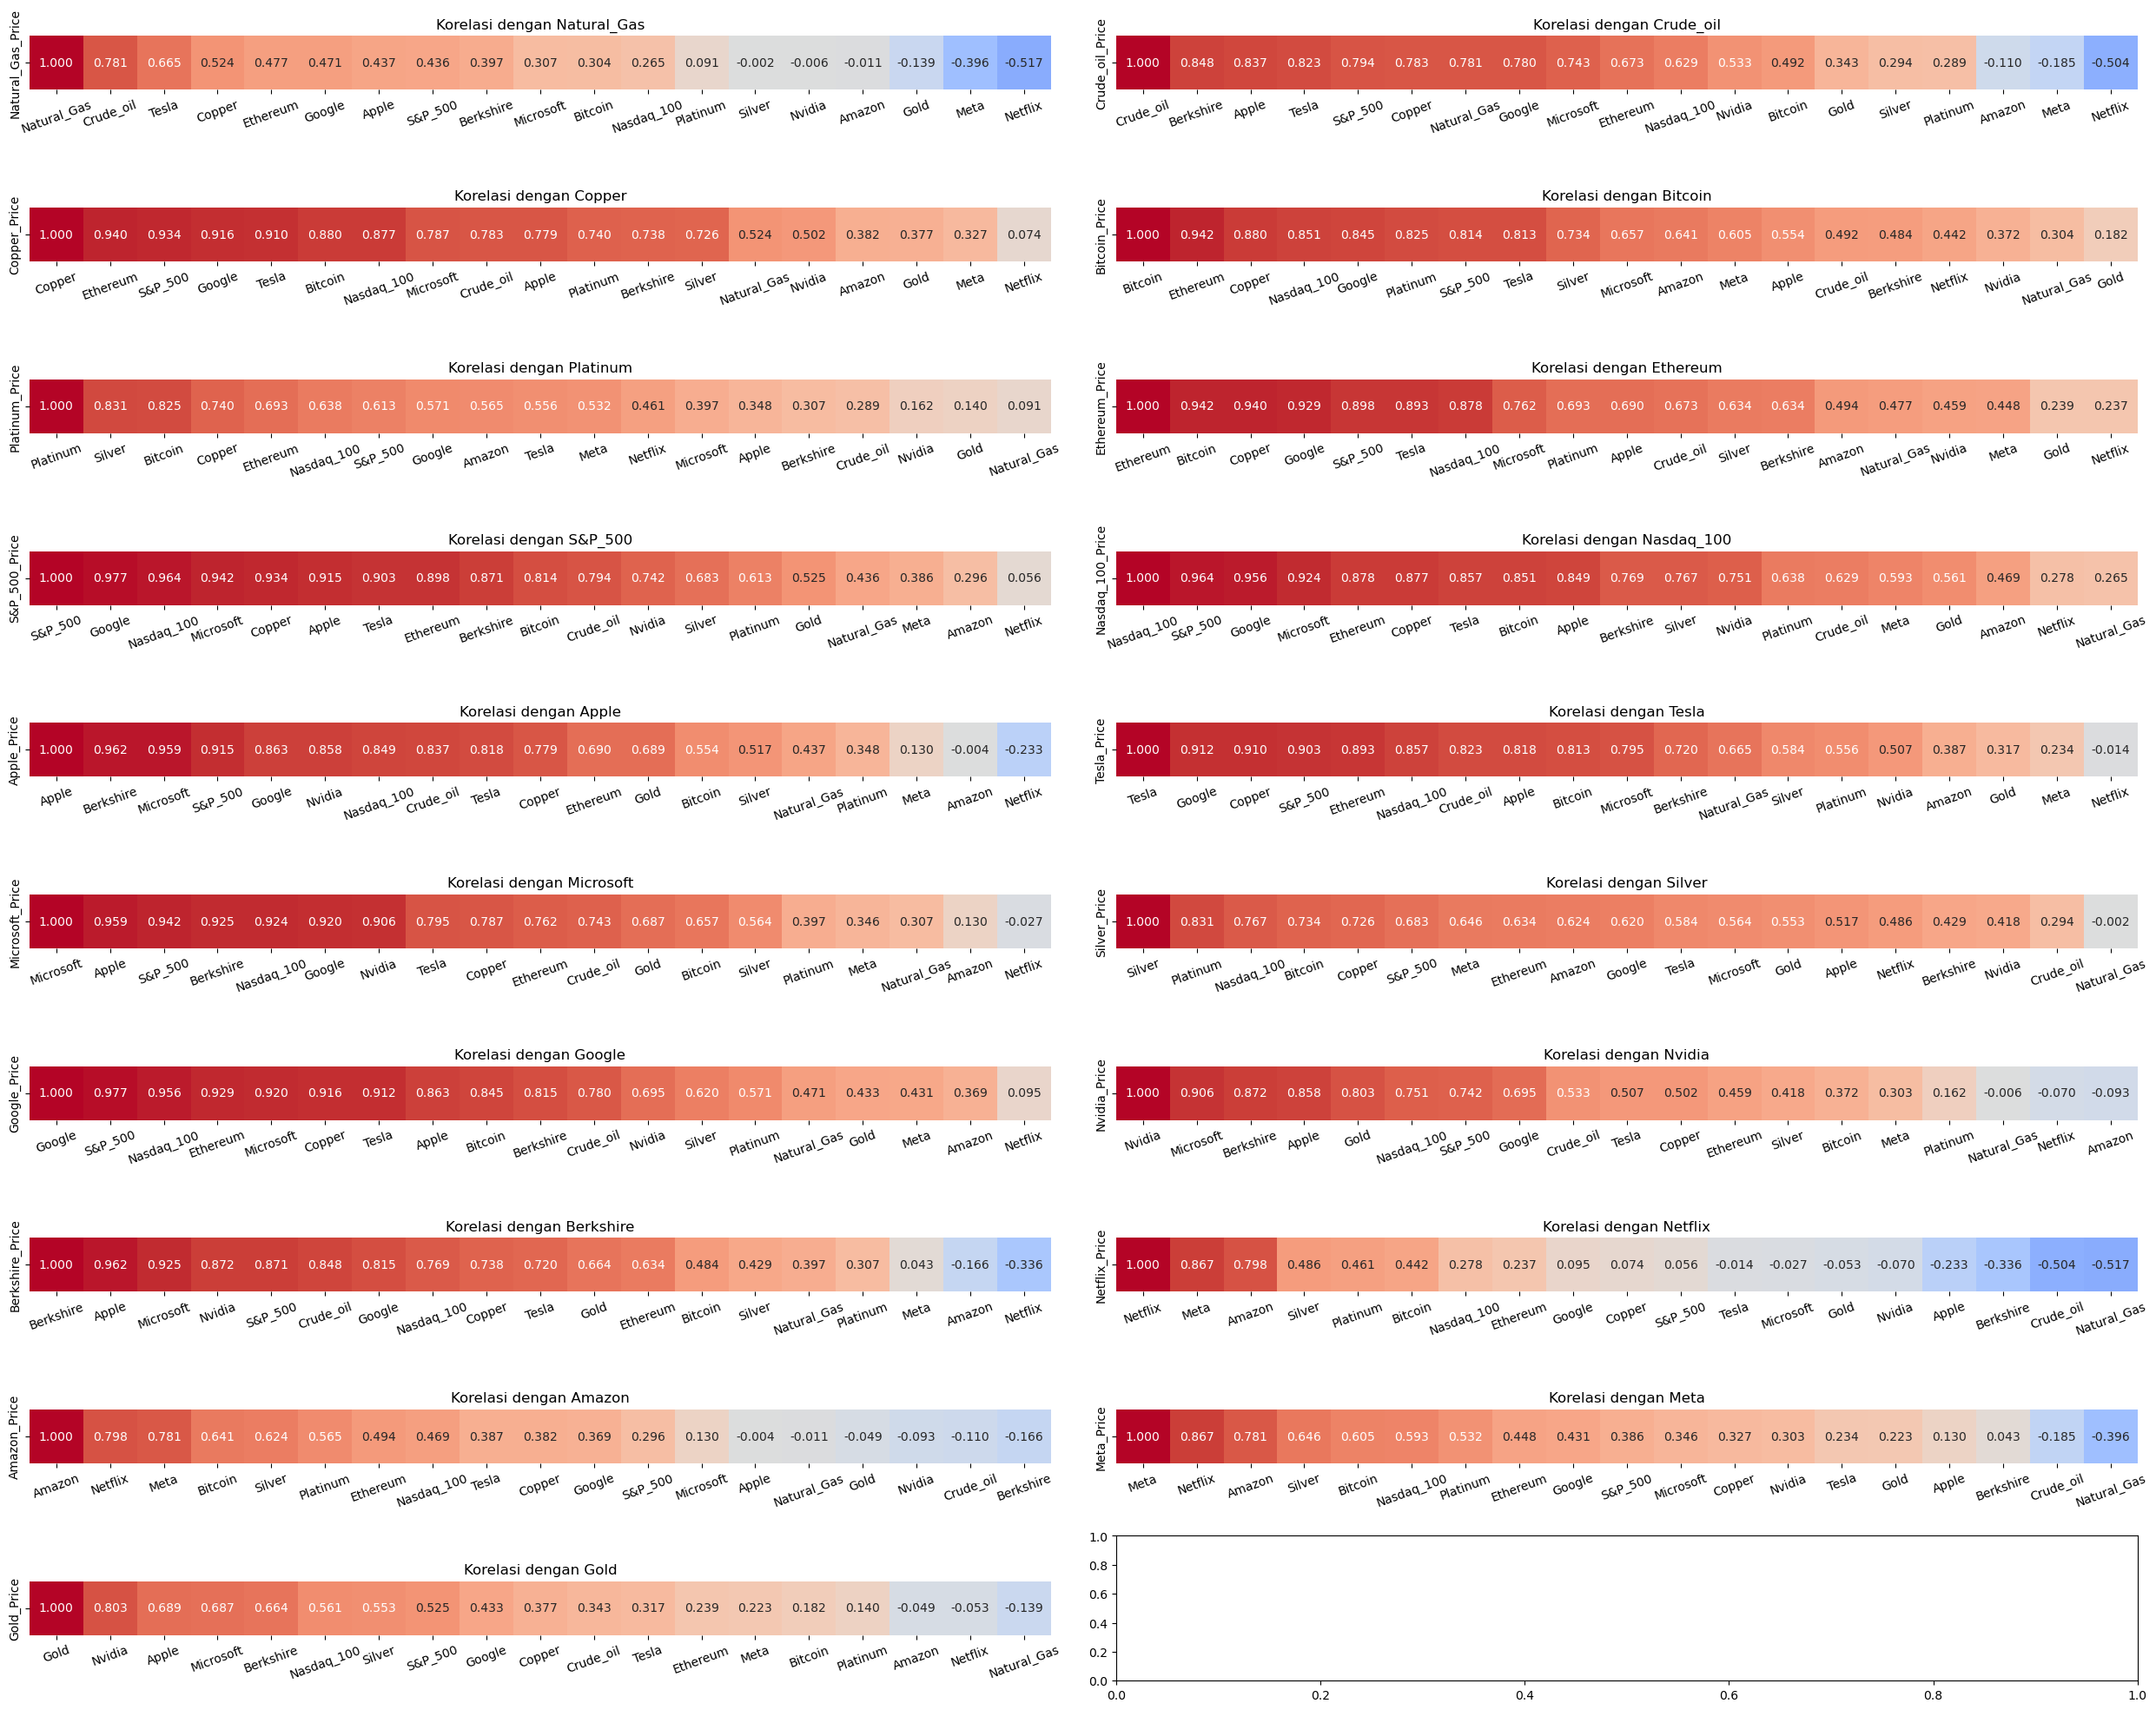

In [32]:
fig, axes = plt.subplots(10, 2, figsize=(25, 20))
axes = axes.flatten()

for i, feature in enumerate(norm_df.columns.tolist()):
  corr_value(axes[i], norm_df, feature)

plt.tight_layout()
plt.show()


In [33]:
def plot_correlation_feature(ax, target, corr_df, norm_df, corr):

  if target in norm_df.columns:
      ax.plot(norm_df[target], label=target,
              linewidth=2, color=colorsbrand_colors[target])

  filter = corr_df[(corr_df['Target'] == target) & (corr_df['Korelasi'] > corr)]

  dict_corr = dict(zip(filter['Fitur'], filter['Korelasi']))

  for fitur, corr in dict_corr.items():
    if fitur != target:
      ax.plot(norm_df[fitur], label=f'{fitur.replace('_Price', '')} korelasi : {corr:.3f}', linewidth=2, color=colorsbrand_colors[fitur], linestyle='--')

  ax.set_title(f'Korelasi dengan {target}')
  ax.legend()

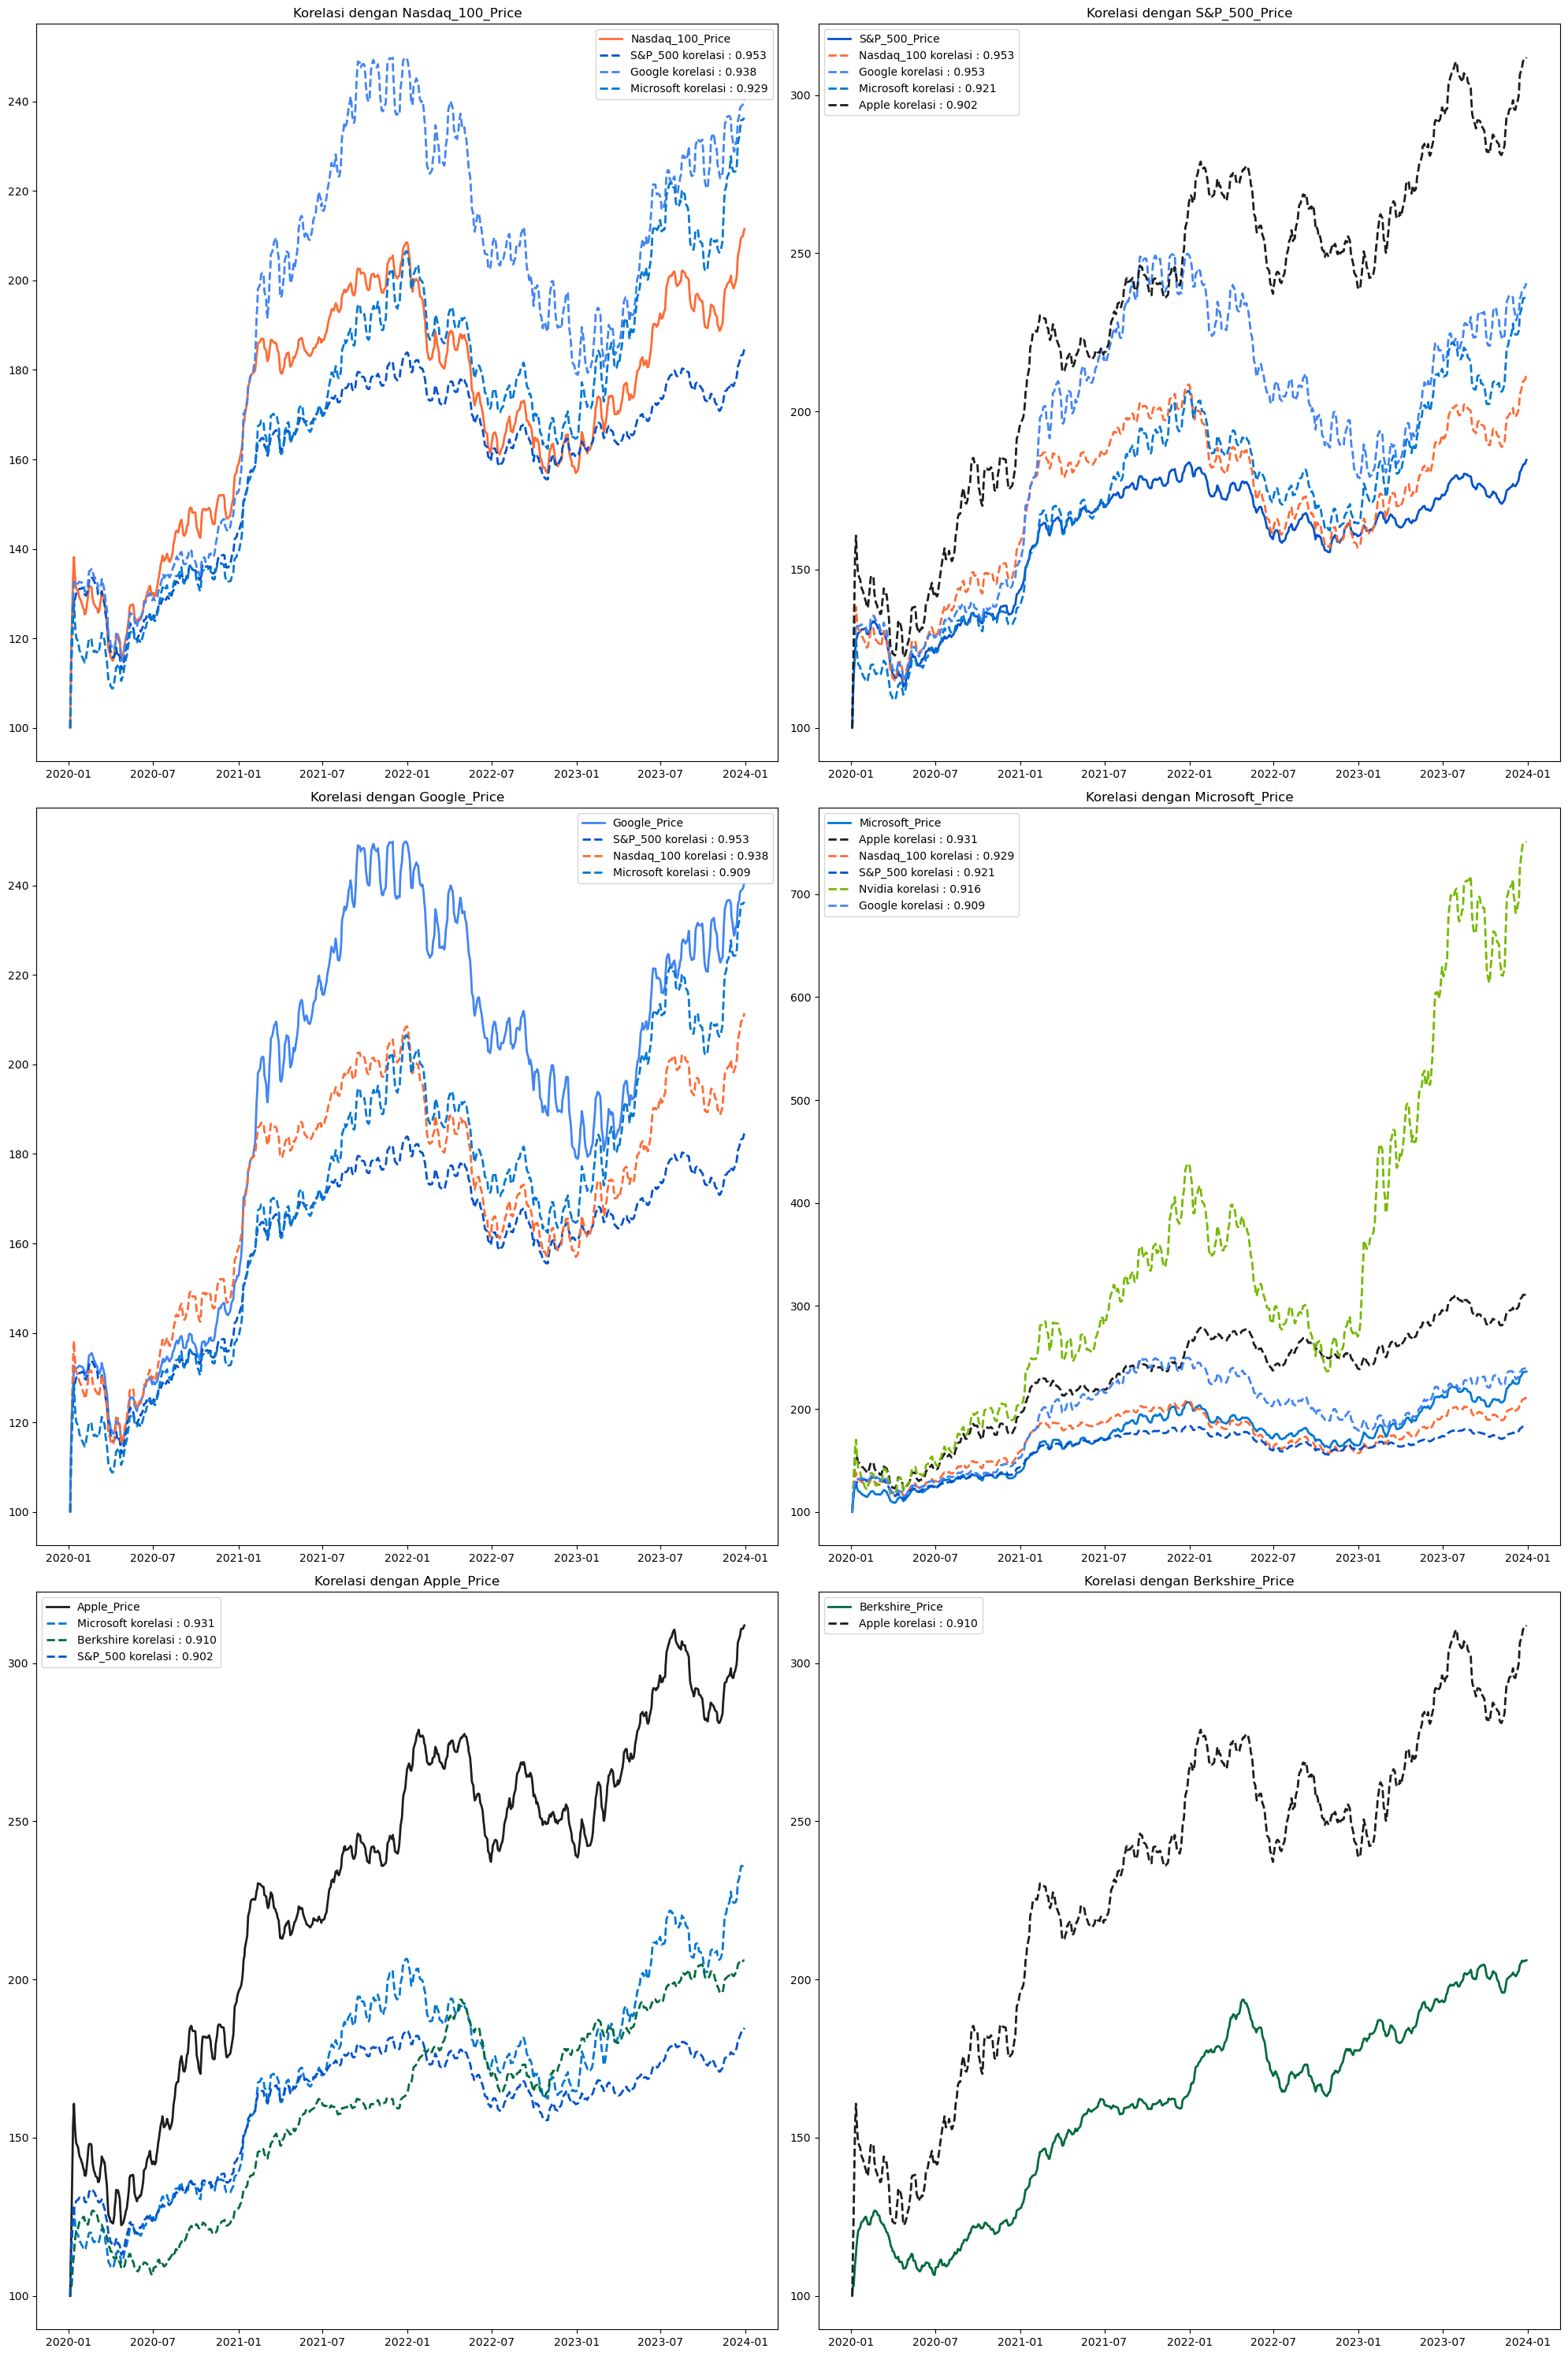

In [34]:
fig, ((ax1, ax2),(ax3, ax4),(ax5, ax6)) = plt.subplots(3, 2, figsize=(20,30))

plot_correlation_feature(ax1, 'Nasdaq_100_Price', corr_df, norm_df,corr=0.9)
plot_correlation_feature(ax2, 'S&P_500_Price', corr_df, norm_df,corr=0.9)
plot_correlation_feature(ax3, 'Google_Price', corr_df, norm_df,corr=0.9)
plot_correlation_feature(ax4, 'Microsoft_Price', corr_df, norm_df,corr=0.9)
plot_correlation_feature(ax5, 'Apple_Price', corr_df, norm_df,corr=0.9)
plot_correlation_feature(ax6, 'Berkshire_Price', corr_df, norm_df,corr=0.9)

plt.tight_layout()
plt.show()

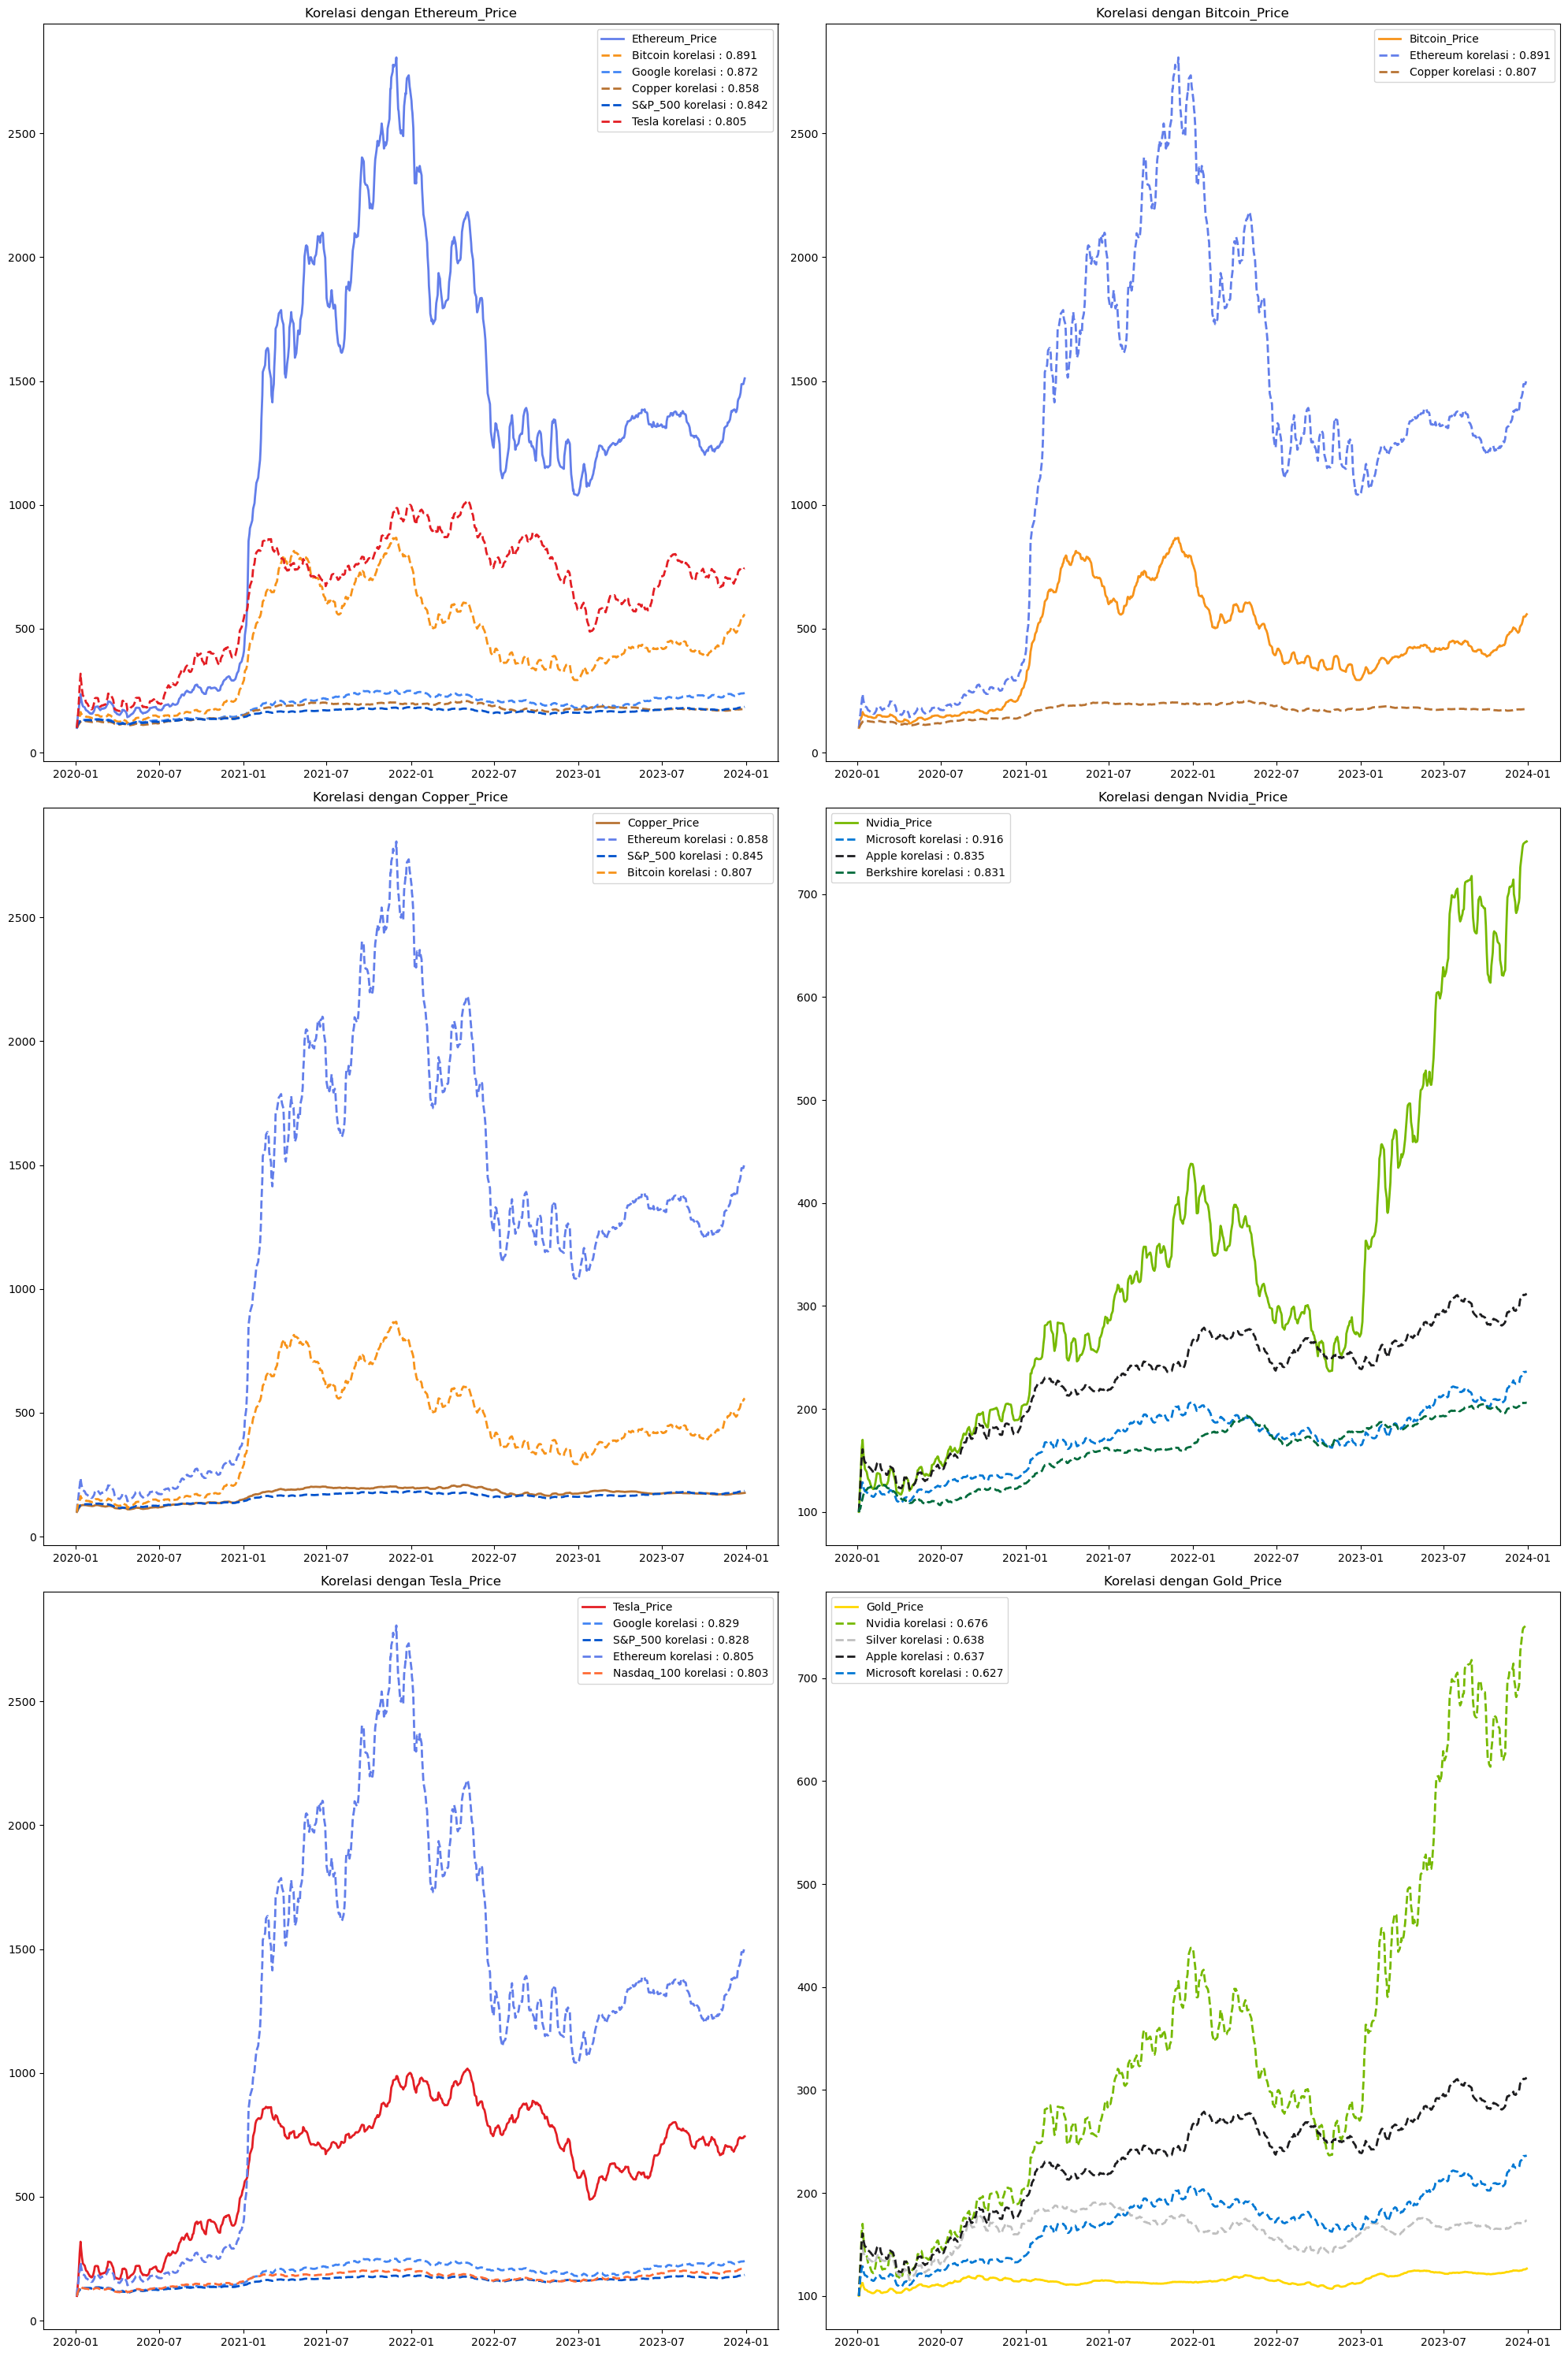

In [35]:
fig, ((ax1, ax2),(ax3, ax4),(ax5, ax6)) = plt.subplots(3, 2, figsize=(20,30))

plot_correlation_feature(ax1, 'Ethereum_Price', corr_df, norm_df,corr=0.8)
plot_correlation_feature(ax2, 'Bitcoin_Price', corr_df, norm_df,corr=0.8)
plot_correlation_feature(ax3, 'Copper_Price', corr_df, norm_df,corr=0.8)
plot_correlation_feature(ax4, 'Nvidia_Price', corr_df, norm_df,corr=0.8)
plot_correlation_feature(ax5, 'Tesla_Price', corr_df, norm_df,corr=0.8)
plot_correlation_feature(ax6, 'Gold_Price', corr_df, norm_df,corr=0.6)

plt.tight_layout()
plt.show()

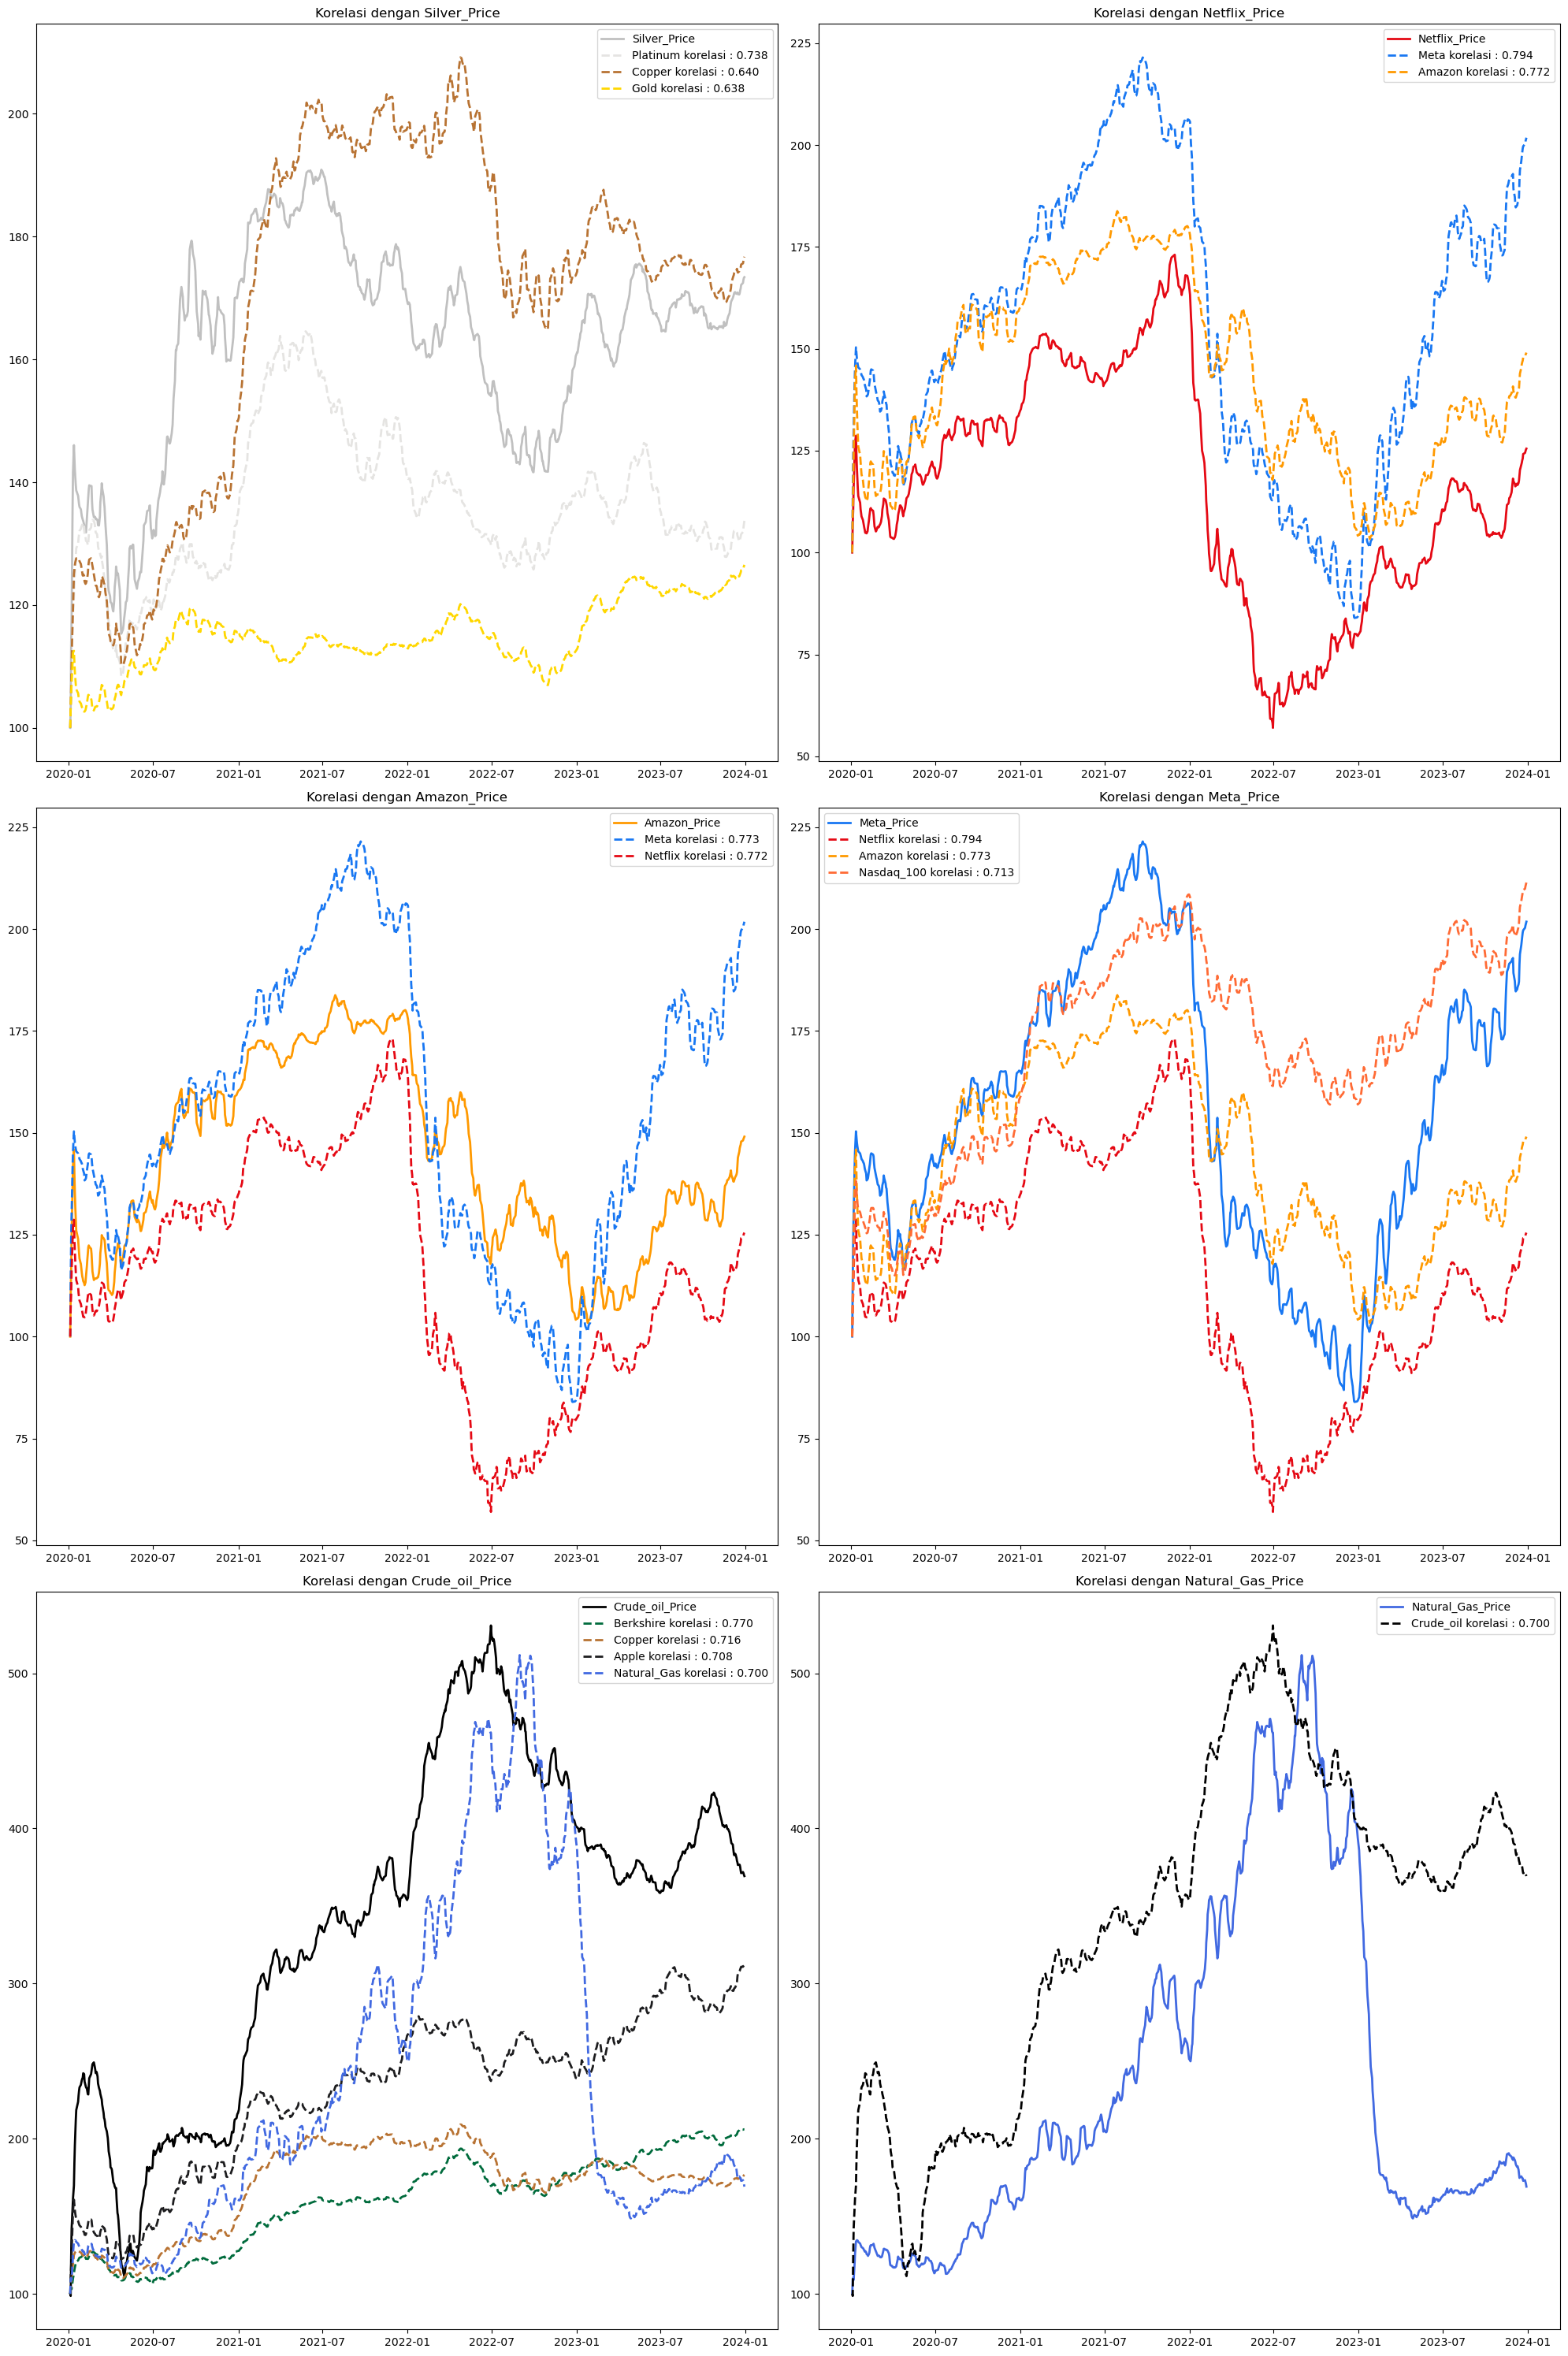

In [36]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(20,30))

plot_correlation_feature(ax1, 'Silver_Price', corr_df, norm_df,corr=0.6)
plot_correlation_feature(ax2, 'Netflix_Price', corr_df, norm_df,corr=0.7)
plot_correlation_feature(ax3, 'Amazon_Price', corr_df, norm_df,corr=0.7)
plot_correlation_feature(ax4, 'Meta_Price', corr_df, norm_df,corr=0.7)
plot_correlation_feature(ax5, 'Crude_oil_Price', corr_df, norm_df,corr=0.7)
plot_correlation_feature(ax6, 'Natural_Gas_Price', corr_df, norm_df,corr=0.7)

plt.tight_layout()
plt.show()

In [37]:
asset_categories = {
    'Tech Stocks': ['Apple_Price', 'Tesla_Price', 'Microsoft_Price', 'Google_Price',
                   'Nvidia_Price', 'Netflix_Price', 'Amazon_Price', 'Meta_Price'],
    'Cryptocurrencies': ['Bitcoin_Price', 'Ethereum_Price'],
    'Commodities': ['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price',
                   'Silver_Price', 'Gold_Price', 'Platinum_Price'],
    'Market Indices': ['S&P_500_Price', 'Nasdaq_100_Price', 'Berkshire_Price']
}

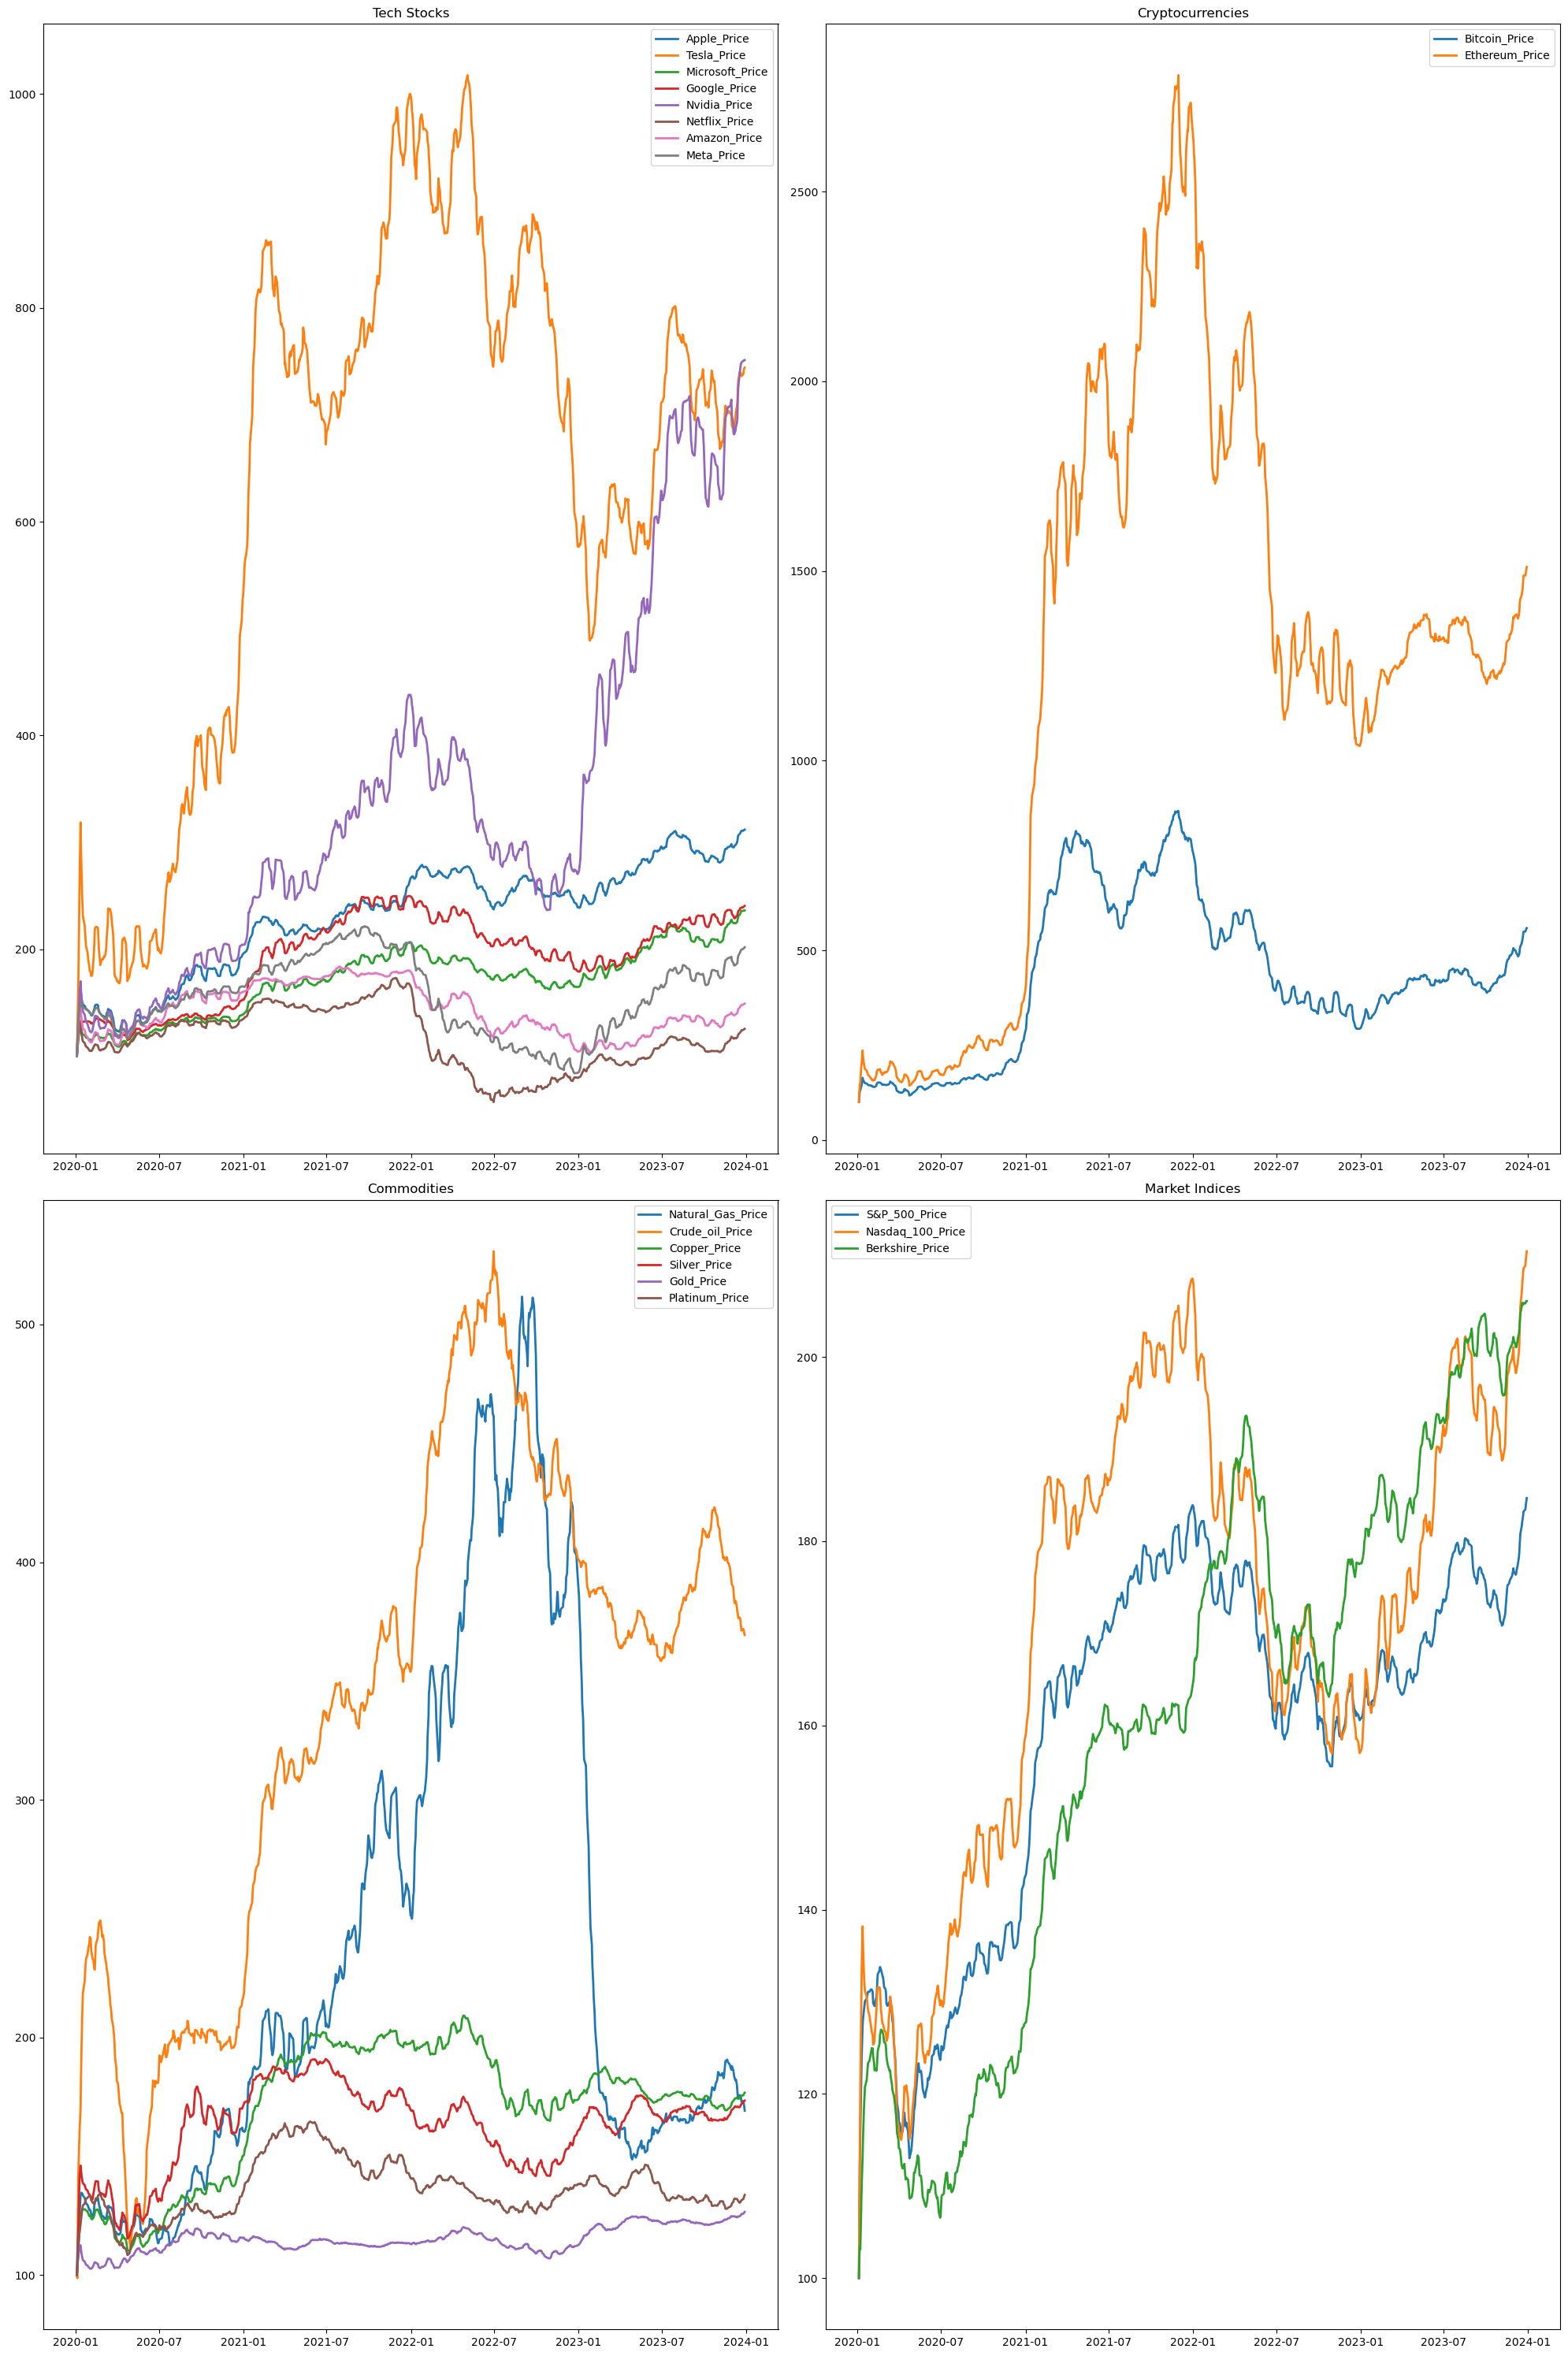

In [38]:
fig, axes = plt.subplots(2,2, figsize=(20,30))

for i, (category, assets) in enumerate(asset_categories.items()):
    ax = axes[i // 2, i % 2]

    for asset in assets:
        ax.plot(norm_df[asset], label=asset, linewidth=2)

    ax.set_title(category)
    ax.legend()

plt.tight_layout()
plt.show()

# EDA Return asset

In [39]:
price_data = df[price_columns].dropna()
returns = price_data.pct_change().dropna()
returns.sort_index(inplace=True)
returns.head()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2020-01-05,0.190926,-0.026096,0.061037,0.328854,0.082742,0.562730,0.145804,0.164553,0.199900,0.456386,0.147656,0.068221,0.195463,0.163238,0.048708,0.140601,0.198239,0.267356,0.068807
2020-01-06,-0.061376,0.791709,0.071799,0.155040,0.156306,0.169670,0.079492,0.101020,0.113325,0.280642,0.047316,0.260343,0.089115,0.245721,0.005931,0.025646,0.080927,0.146537,0.029043
2020-01-07,-0.058061,0.123589,0.103309,-0.094158,-0.070921,-0.068637,0.019678,0.070879,0.131370,0.246701,0.119619,-0.032347,0.005018,0.082217,-0.031132,0.140214,0.165034,0.024320,0.016911
2020-01-09,0.512268,0.073832,0.105523,0.290902,0.149381,1.060186,0.131838,0.195891,0.474020,1.121517,0.110259,0.572346,0.147712,0.450262,0.226275,0.146014,0.215506,0.243696,0.111804
2020-01-10,0.000000,-0.094481,-0.051944,-0.108637,-0.057624,-0.257945,-0.041357,-0.057729,-0.129602,-0.056584,-0.065165,-0.153290,-0.101027,-0.014905,-0.026997,-0.052179,-0.079447,-0.097516,-0.031634


In [40]:
returns.index.year.value_counts()

Date
2023    250
2020    248
2021    246
2022    245
Name: count, dtype: int64

In [41]:
print(returns.shape)
print(returns.info())

(989, 19)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 989 entries, 2020-01-05 to 2023-12-29
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Natural_Gas_Price  989 non-null    float64
 1   Crude_oil_Price    989 non-null    float64
 2   Copper_Price       989 non-null    float64
 3   Bitcoin_Price      989 non-null    float64
 4   Platinum_Price     989 non-null    float64
 5   Ethereum_Price     989 non-null    float64
 6   S&P_500_Price      989 non-null    float64
 7   Nasdaq_100_Price   989 non-null    float64
 8   Apple_Price        989 non-null    float64
 9   Tesla_Price        989 non-null    float64
 10  Microsoft_Price    989 non-null    float64
 11  Silver_Price       989 non-null    float64
 12  Google_Price       989 non-null    float64
 13  Nvidia_Price       989 non-null    float64
 14  Berkshire_Price    989 non-null    float64
 15  Netflix_Price      989 non-null    float64
 1

# Cummulative Analisis

In [42]:
initial_investment = 1000

df_cummulative = initial_investment * (1 + returns).cumprod()
df_cummulative.head()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2020-01-05,1190.926276,973.904481,1061.037173,1328.854410,1082.742317,1562.730355,1145.804493,1164.552803,1199.900382,1456.386293,1147.656301,1068.220824,1195.462795,1163.238440,1048.708134,1140.600967,1198.238809,1267.355890,1068.807339
2020-01-06,1117.832388,1744.953225,1137.218908,1534.879867,1251.981644,1827.878520,1236.887270,1282.195854,1335.879130,1865.109034,1201.959109,1346.324371,1301.996370,1449.070265,1054.928230,1169.852780,1295.209141,1453.070175,1099.849189
2020-01-07,1052.930057,1960.610537,1254.703993,1390.359268,1163.190099,1702.417809,1261.226472,1373.076651,1511.373070,2325.233645,1345.736638,1302.774600,1308.529946,1568.207997,1022.086124,1333.882663,1508.963204,1488.408521,1118.449164
2020-01-09,1592.312539,2105.366814,1387.104176,1794.818106,1336.948964,3507.297656,1427.504554,1642.049667,2227.793458,4933.021807,1494.116100,2048.412471,1501.814882,2274.312983,1253.358852,1528.647550,1834.154524,1851.127820,1243.496293
2020-01-10,1592.312539,1906.450025,1315.052777,1599.834300,1259.908219,2602.609465,1368.467921,1547.255049,1939.066910,4653.894081,1396.752350,1734.410755,1350.090744,2240.414678,1219.521531,1448.884860,1688.436943,1670.614035,1204.159859


In [43]:
df_cummulative.columns

Index(['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Bitcoin_Price',
       'Platinum_Price', 'Ethereum_Price', 'S&P_500_Price', 'Nasdaq_100_Price',
       'Apple_Price', 'Tesla_Price', 'Microsoft_Price', 'Silver_Price',
       'Google_Price', 'Nvidia_Price', 'Berkshire_Price', 'Netflix_Price',
       'Amazon_Price', 'Meta_Price', 'Gold_Price'],
      dtype='object')

In [44]:
for col in df_cummulative.columns:
  df_cummulative[col] = df_cummulative[col].rolling(window=30, min_periods=1).mean()

In [45]:
asset_cummulative = {
    'Cryptocurrencies': ['Bitcoin_Price', 'Ethereum_Price'],
    'Traditional_asset': ['S&P_500_Price', 'Gold_Price'],
    'Tech_stocks': ['Apple_Price', 'Tesla_Price', 'Microsoft_Price', 'Google_Price', 'Nvidia_Price', 'Netflix_Price', 'Amazon_Price', 'Meta_Price'],
    'Commodities': ['Natural_Gas_Price', 'Crude_oil_Price']
}

# Return Analisis

In [46]:
returns.head()

,Natural_Gas_Price,Crude_oil_Price,Copper_Price,Bitcoin_Price,Platinum_Price,Ethereum_Price,S&P_500_Price,Nasdaq_100_Price,Apple_Price,Tesla_Price,Microsoft_Price,Silver_Price,Google_Price,Nvidia_Price,Berkshire_Price,Netflix_Price,Amazon_Price,Meta_Price,Gold_Price
Date,,,,,,,,,,,,,,,,,,,
2020-01-05,0.190926,-0.026096,0.061037,0.328854,0.082742,0.562730,0.145804,0.164553,0.199900,0.456386,0.147656,0.068221,0.195463,0.163238,0.048708,0.140601,0.198239,0.267356,0.068807
2020-01-06,-0.061376,0.791709,0.071799,0.155040,0.156306,0.169670,0.079492,0.101020,0.113325,0.280642,0.047316,0.260343,0.089115,0.245721,0.005931,0.025646,0.080927,0.146537,0.029043
2020-01-07,-0.058061,0.123589,0.103309,-0.094158,-0.070921,-0.068637,0.019678,0.070879,0.131370,0.246701,0.119619,-0.032347,0.005018,0.082217,-0.031132,0.140214,0.165034,0.024320,0.016911
2020-01-09,0.512268,0.073832,0.105523,0.290902,0.149381,1.060186,0.131838,0.195891,0.474020,1.121517,0.110259,0.572346,0.147712,0.450262,0.226275,0.146014,0.215506,0.243696,0.111804
2020-01-10,0.000000,-0.094481,-0.051944,-0.108637,-0.057624,-0.257945,-0.041357,-0.057729,-0.129602,-0.056584,-0.065165,-0.153290,-0.101027,-0.014905,-0.026997,-0.052179,-0.079447,-0.097516,-0.031634


In [47]:
return_stats = pd.DataFrame({
    'Mean_daily_return': returns.mean(),
    'Std_daily_return': returns.std(),
    'Min_daily_return': returns.min(),
    'Max_daily_return': returns.max(),
    'Annualized_return': (returns.mean() * 252),
    'Annualized_volality': (returns.std() * np.sqrt(252))
})
return_stats.sort_values('Annualized_return', ascending=False)

,Mean_daily_return,Std_daily_return,Min_daily_return,Max_daily_return,Annualized_return,Annualized_volality
Ethereum_Price,0.035412,0.268195,-0.782597,1.988925,8.923916,4.257459
Tesla_Price,0.027158,0.219067,-0.820490,1.121517,6.843880,3.477577
Bitcoin_Price,0.021935,0.213362,-0.712643,1.557752,5.527579,3.387011
Nvidia_Price,0.020236,0.185523,-0.683355,1.257188,5.099460,2.945081
Meta_Price,0.015434,0.196314,-0.582118,2.589201,3.889274,3.116382
Natural_Gas_Price,0.013948,0.162814,-0.563195,0.882671,3.514929,2.584599
Netflix_Price,0.012267,0.174282,-0.521925,2.094070,3.091304,2.766647
Crude_oil_Price,0.007157,0.182487,-3.059661,1.693737,1.803670,2.896890
Amazon_Price,0.007083,0.116459,-0.449145,0.711311,1.784984,1.848728
Google_Price,0.005466,0.094204,-0.406890,0.509649,1.377355,1.495443


In [48]:
def return_year(tahun):
  year_stat = returns[returns.index.year == tahun]

  return_stats = pd.DataFrame({
    'Mean_daily_return': year_stat.mean(),
    'Std_daily_return': year_stat.std(),
    'Min_daily_return': year_stat.min(),
    'Max_daily_return': year_stat.max(),
    'Annualized_return': (year_stat.mean() * 252),
    'Annualized_volality': (year_stat.std() * np.sqrt(252)),
    'Januari_return': year_stat[year_stat.index.month == 1].mean(),
    'Februari_return': year_stat[year_stat.index.month == 2].mean(),
    'Maret_return': year_stat[year_stat.index.month == 3].mean(),
    'April_return': year_stat[year_stat.index.month == 4].mean(),
    'Mei_return': year_stat[year_stat.index.month == 5].mean(),
    'Juni_return': year_stat[year_stat.index.month == 6].mean(),
    'Juli_return': year_stat[year_stat.index.month == 7].mean(),
    'Agustus_return': year_stat[year_stat.index.month == 8].mean(),
    'September_return': year_stat[year_stat.index.month == 9].mean(),
    'Oktober_return': year_stat[year_stat.index.month == 10].mean(),
    'November_return': year_stat[year_stat.index.month == 11].mean(),
    'Desember_return': year_stat[year_stat.index.month == 12].mean()
  })
  return return_stats.sort_values('Annualized_return', ascending=False)

In [49]:
def return_month(bulan, tahun):
  year_return = return_year(tahun)
  bulan = year_return[bulan].sort_values(ascending=False)

  plt.figure(figsize=(20, 8))
  plt.bar(range(len(bulan)), bulan.values)

  for i, value in enumerate(bulan.values):
    plt.text(i, value, f'{value:.1%}', ha='center', va='bottom', fontsize=8)

  plt.title(f"Return {bulan.name} tahun {tahun}")
  plt.xticks(range(len(bulan)), bulan.index, rotation=30)
  plt.xlabel('Month')
  plt.ylabel('Return')
  plt.show()

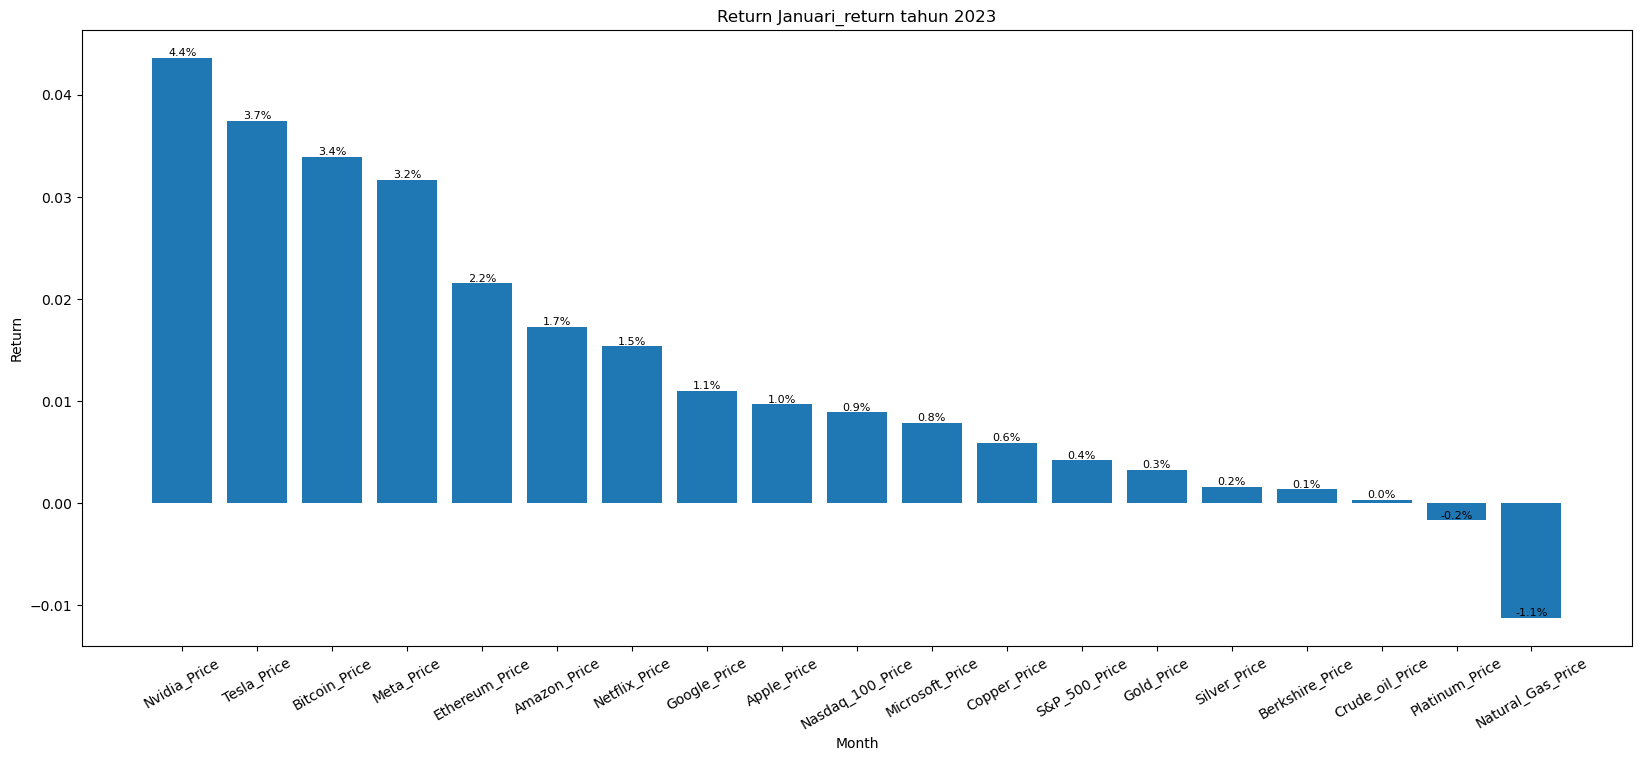

In [50]:
return_month('Januari_return', 2023)

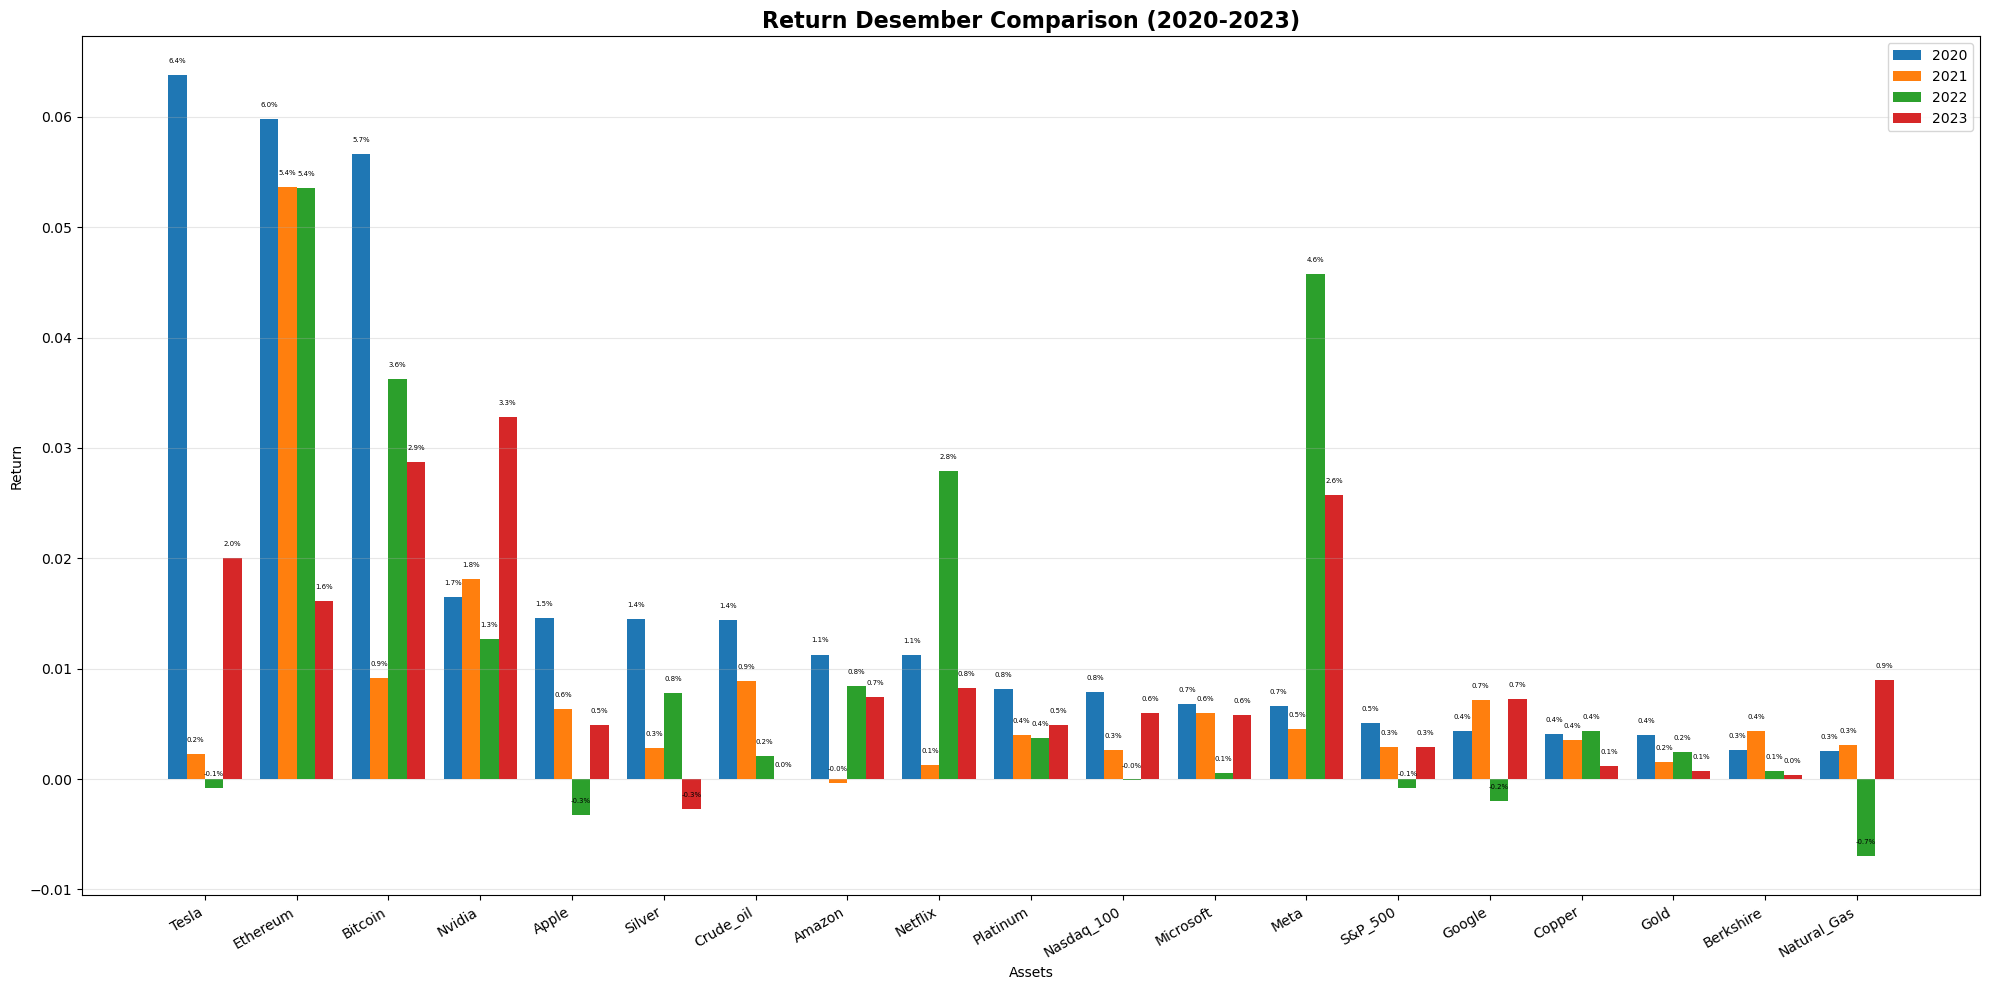

In [51]:
data = {}
bulan = 'Desember_return'
years = [2020, 2021, 2022, 2023]
for year in years:
  data_year = return_year(year)
  data[year] = data_year[bulan].sort_values(ascending=False)

assets = data[years[0]].index

x = np.arange(len(assets))
width = 0.2

plt.figure(figsize=(20, 10))

for i, year in enumerate(years):
  offset = (i - len(years)/2 + 0.5) * width
  values = [data[year][asset] for asset in assets]

  bars = plt.bar(x + offset, values, width, label=f'{year}')

  for j, value in enumerate(values):
    plt.text(x[j] + offset, value + 0.001, f'{value:.1%}', ha='center', va='bottom', fontsize=5)

plt.title(f"Return {bulan.replace('_return', '')} Comparison (2020-2023)", fontsize=16, fontweight='bold')
plt.xticks(x, [asset.replace('_Price', '') for asset in assets], rotation=30, ha='right')
plt.xlabel('Assets')
plt.ylabel('Return')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
def compare_year_return(month, assets):
  selected_assets = assets
  years = [2020, 2021, 2022, 2023]

  data = {}
  for asset in selected_assets:
    data[asset] = [return_year(year).loc[asset, month] for year in years]

  x = np.arange(len(years))
  width = 0.2

  fig, ax = plt.subplots(figsize=(20, 8))
  for i, (asset, value) in enumerate(data.items()):
    bars = ax.bar(x + i * width, value, width, label=asset.replace('_Price', ''), color=colorsbrand_colors[asset])
    for bar, value in zip(bars, value):
      height = bar.get_height()
      ax.text(bar.get_x() + bar.get_width()/2, height, f'{value:.1%}', ha='center', va='bottom', fontsize=8)

  ax.set_title(f"Return Comparation Bulan {month.replace('_return', ' ')}")
  ax.set_xticks(x + width * (len(selected_assets) - 1) / 2)
  ax.set_xticklabels(years)
  ax.set_xlabel('Year')
  ax.set_ylabel('Return')
  ax.legend()
  plt.show()

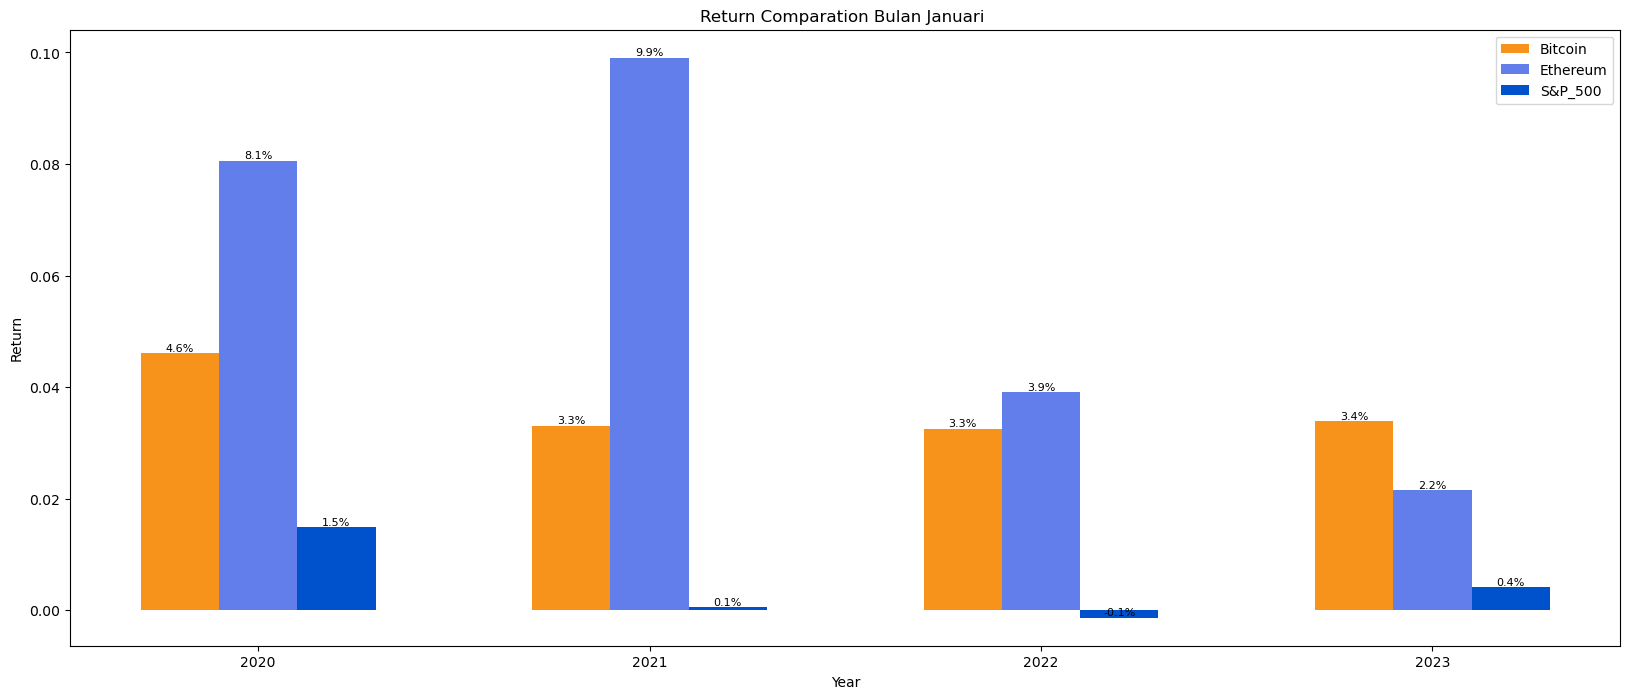

In [53]:
compare_year_return('Januari_return', ['Bitcoin_Price', 'Ethereum_Price', 'S&P_500_Price'])

# Portofolio analisis

In [54]:
tahun = 2020
assets_pilihan = ['Bitcoin_Price', 'Tesla_Price', 'Apple_Price', 'Ethereum_Price']
jumlah_investasi = 1200

year_data = return_year(tahun)

returns_analisis = year_data.loc[assets_pilihan, ['Annualized_return']].copy()
returns_analisis = returns_analisis.sort_values('Annualized_return',ascending=False)
returns_analisis.reset_index(inplace=True)
returns_analisis.columns = ['Asset', 'Annualized_return']

positive_returns = returns_analisis[returns_analisis['Annualized_return'] > 0]

total_returns = positive_returns['Annualized_return'].sum()

positive_returns['Allocation_Pct'] = positive_returns['Annualized_return'] / total_returns
positive_returns['Allocation_USD'] = positive_returns['Allocation_Pct'] * jumlah_investasi
positive_returns['Expect_return'] = positive_returns['Allocation_USD'] * positive_returns['Annualized_return']
positive_returns['Profit'] = positive_returns['Expect_return'] - jumlah_investasi


In [55]:
positive_returns

,Asset,Annualized_return,Allocation_Pct,Allocation_USD,Expect_return,Profit
0,Tesla_Price,16.507005,0.420377,504.452655,8327.002652,7127.002652
1,Ethereum_Price,12.542714,0.319420,383.304267,4807.675943,3607.675943
2,Bitcoin_Price,7.218114,0.183821,220.584933,1592.207151,392.207151
3,Apple_Price,2.999293,0.076382,91.658145,274.909664,-925.090336


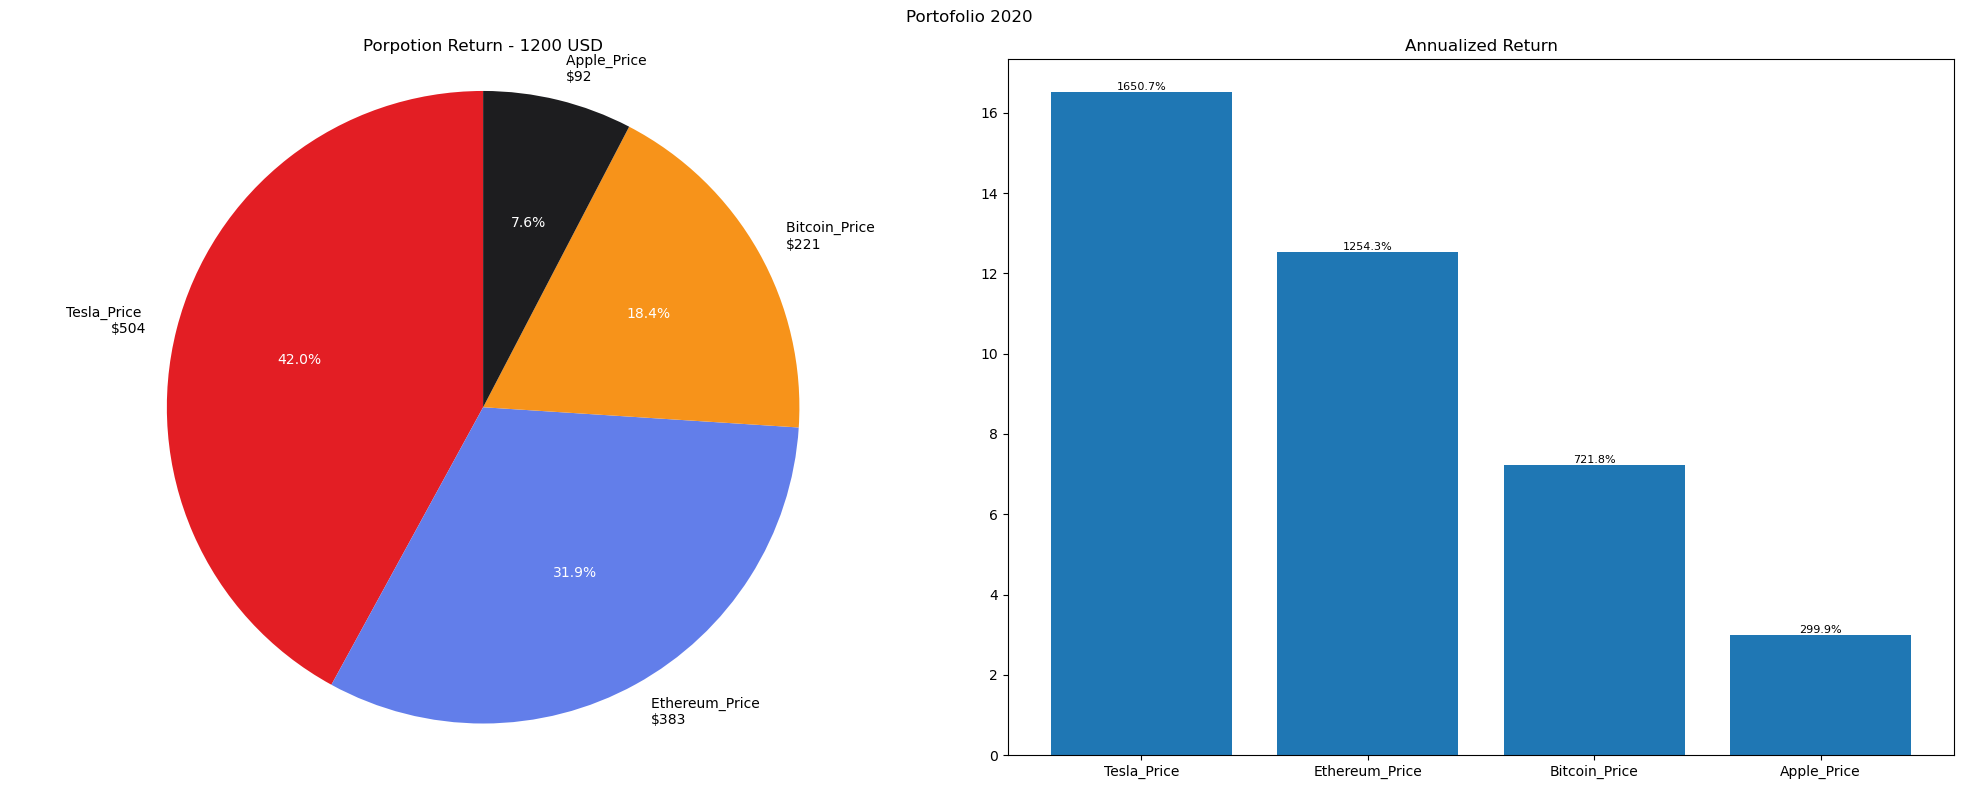

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"Portofolio {tahun}")

sizes = positive_returns['Allocation_Pct']

labels = []
for i, row in positive_returns.iterrows():
  asset = row['Asset']
  allocation_usd = row['Allocation_USD']
  labels.append(f"{asset} \n${allocation_usd:.0f}")

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10}, colors=[colorsbrand_colors[asset] for asset in positive_returns['Asset']])

for autotext in autotexts:
  autotext.set_color('white')

ax1.axis('equal')
ax1.set_title(f"Porpotion Return - {jumlah_investasi} USD")

returns_bar = positive_returns['Annualized_return']
ax2.bar(positive_returns['Asset'], returns_bar)
for i, value in enumerate(returns_bar):
  ax2.text(i, value, f'{value:.1%}', ha='center', va='bottom', fontsize=8)

ax2.set_title(f"Annualized Return")

plt.tight_layout()
plt.show()

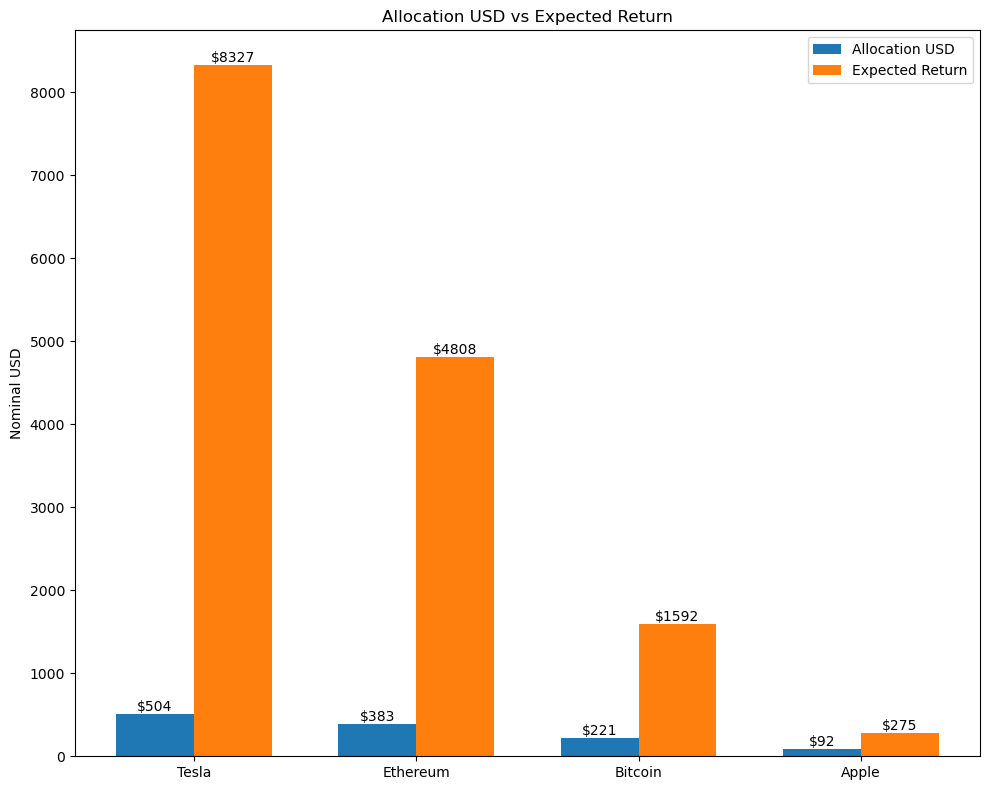

In [57]:
assets = positive_returns['Asset'].str.replace('_Price', '')
expect_return = positive_returns['Expect_return']
allocated_usd = positive_returns['Allocation_USD']

x = np.arange(len(assets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 8))

bar1 = ax.bar(x - width/2, allocated_usd, width, label='Allocation USD')
bar2 = ax.bar(x + width/2, expect_return, width, label='Expected Return')

ax.set_title('Allocation USD vs Expected Return')

ax.set_ylabel('Nominal USD')
ax.set_xticks(x)
ax.set_xticklabels(assets)
ax.legend()

for i in bar1:
  height =  i.get_height()
  ax.text(i.get_x() + i.get_width()/2, height, f'${height:.0f}', ha='center', va='bottom', fontsize=10)

for i in bar2:
  height =  i.get_height()
  ax.text(i.get_x() + i.get_width()/2, height, f'${height:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Simpan file

In [58]:
df.index[0]

Timestamp('2020-01-04 00:00:00')

In [59]:
df[price_columns].to_csv('CSV_US_Stock_Data_Cleaned.csv', index=True)

In [61]:
df[price_columns].to_parquet('US_Stock_Data_Cleaned.csv', index=True)

In [ ]:
df